In [1]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np
import pandas as pd
import matplotlib
import matplotlib as mpl
import matplotlib.dates as dates
import matplotlib.pyplot as plt
import copy
import math
import scipy as sp
from scipy import optimize
from scipy.integrate import odeint
from scipy.interpolate import CubicSpline
from prettytable import PrettyTable  
import datetime as dt
import timeit
import time
import os
import sys
import time
import random
from sklearn.metrics import mean_squared_error, mean_absolute_error
sys.path.insert(0, '../../Utilities/')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
np.set_printoptions(threshold=np.inf)

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
data = pd.read_csv("EINN_21day.csv")

alpha1 = 1.0 #data
alpha2 = 1.0

N0 = 6629870
lb = 0
ub = 21

POINTS = 1
SEED = 123
GRID = 5

npoints = ub * POINTS
epochs = 100000

layers = [1,128,128,128,128,16]
n_mc = 10
learning_rate = 1e-6
length = int(ub-lb)


In [3]:
birth_rt = 0.000053
death_rt = 0.000033

alpha_cal = 0.00135
sigma_cal = 0.06352
beta1_cal = 0.2812
beta2_cal = 0.15838
beta3_cal = 0.0388
delta1_cal = 0.28505
delta2_cal = 0.28269
delta3_cal = 0.14206
gamma_cal = 0.30954
p1_cal = 0.01845
p2_cal = 0.1431
mu_cal = 0.0042
sigma1_cal = 0.09275
sigma2_cal = 0.03887
sigma3_cal = 0.07517
sigma4_cal = 0.06302
sigma5_cal = 0.07878
sigma6_cal = 0.06123
sigma7_cal = 0.0611
sigma8_cal = 0.06199

new_red = (243/255, 114/255, 82/255)
new_orange = (252/255, 180/255, 97/255)
new_green = (127/255, 198/255, 211/255)
new_purple = (111/255, 120/255, 185/255)


In [4]:
class ClipConstraint(tf.keras.constraints.Constraint):
    def __init__(self, min_value, max_value):
        self.min_value = min_value
        self.max_value = max_value

    def __call__(self, w):
        return tf.clip_by_value(w, self.min_value, self.max_value)

class SIR:
    def __init__(self, S, V, E, I1, I2, I3, R, D, T, layers, alpha1, alpha2, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8, n_mc):
        self.t = T
        self.S = S
        self.V = V
        self.E = E
        self.I1 = I1
        self.I2 = I2
        self.I3 = I3
        self.R = R
        self.D = D
        self.dW1 = dW1
        self.dW2 = dW2
        self.dW3 = dW3
        self.dW4 = dW4
        self.dW5 = dW5
        self.dW6 = dW6
        self.dW7 = dW7
        self.dW8 = dW8
        
        self.learning_rate = learning_rate 
        
        self.n_mc = n_mc
        self.alpha1, self.alpha2 = alpha1, alpha2


        self.layers = layers
        self.lb = T.min()
        self.ub = T.max()

        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        self.birth = tf.Variable(birth_rt ,dtype=tf.float32,trainable=False)
        self.dead = tf.Variable(death_rt,dtype=tf.float32,trainable=False)
        
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        
        #trainable parameters
        self.grid = GRID
        self.alpha = tf.Variable(alpha_cal,dtype=tf.float32,trainable=False)
        self.sigma = tf.Variable(sigma_cal,dtype=tf.float32,trainable=False)
        self.beta1 = tf.Variable(beta1_cal,dtype=tf.float32,trainable=False)
        self.beta2 = tf.Variable(beta2_cal,dtype=tf.float32,trainable=False)
        self.beta3 = tf.Variable(beta3_cal,dtype=tf.float32,trainable=False)
        self.delta1 = tf.Variable(delta1_cal,dtype=tf.float32,trainable=False)
        self.delta2 = tf.Variable(delta2_cal,dtype=tf.float32,trainable=False)
        self.delta3 = tf.Variable(delta3_cal,dtype=tf.float32,trainable=False)
        self.mu = tf.Variable(mu_cal,dtype=tf.float32,trainable=False)
        self.gamma = tf.Variable(gamma_cal,dtype=tf.float32,trainable=False)
        self.p1 = tf.Variable(p1_cal,dtype=tf.float32,trainable=False)
        self.p2 = tf.Variable(p2_cal,dtype=tf.float32,trainable=False)
        self.sigma1 = tf.Variable(sigma1_cal,dtype=tf.float32,trainable=False)
        self.sigma2 = tf.Variable(sigma2_cal,dtype=tf.float32,trainable=False)
        self.sigma3 = tf.Variable(sigma3_cal,dtype=tf.float32,trainable=False)
        self.sigma4 = tf.Variable(sigma4_cal,dtype=tf.float32,trainable=False)
        self.sigma5 = tf.Variable(sigma5_cal,dtype=tf.float32,trainable=False)
        self.sigma6 = tf.Variable(sigma6_cal,dtype=tf.float32,trainable=False)
        self.sigma7 = tf.Variable(sigma7_cal,dtype=tf.float32,trainable=False)
        self.sigma8 = tf.Variable(sigma8_cal,dtype=tf.float32,trainable=False)


        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        # Initialize NN
        self.weights1, self.biases1 = self.initialize_NN(self.layers)
        self.weights2, self.biases2 = self.initialize_NN(self.layers)
        self.weights3, self.biases3 = self.initialize_NN(self.layers)
        self.weights4, self.biases4 = self.initialize_NN(self.layers)
        self.weights5, self.biases5 = self.initialize_NN(self.layers)
        self.weights6, self.biases6 = self.initialize_NN(self.layers)
        self.weights7, self.biases7 = self.initialize_NN(self.layers)
        self.weights8, self.biases8 = self.initialize_NN(self.layers)
        self.weights9, self.biases9 = self.initialize_NN(self.layers)
        self.weights10, self.biases10 = self.initialize_NN(self.layers)
        self.weights11, self.biases11 = self.initialize_NN(self.layers)
        self.weights12, self.biases12 = self.initialize_NN(self.layers)
        self.weights13, self.biases13 = self.initialize_NN(self.layers)
        self.weights14, self.biases14 = self.initialize_NN(self.layers)
        self.weights15, self.biases15 = self.initialize_NN(self.layers)
        self.weights16, self.biases16 = self.initialize_NN(self.layers)
     
        self.sess = tf.Session(config=tf.ConfigProto(allow_soft_placement=True,
                                                     log_device_placement=True))
        self.t_tf = tf.placeholder(tf.float32, shape=[None, self.t.shape[1]])
        self.S_tf = tf.placeholder(tf.float32, shape=[None, self.S.shape[1]])
        self.V_tf = tf.placeholder(tf.float32, shape=[None, self.V.shape[1]])
        self.E_tf = tf.placeholder(tf.float32, shape=[None, self.E.shape[1]])
        self.I1_tf = tf.placeholder(tf.float32, shape=[None, self.I1.shape[1]])
        self.I2_tf = tf.placeholder(tf.float32, shape=[None, self.I2.shape[1]])
        self.I3_tf = tf.placeholder(tf.float32, shape=[None, self.I3.shape[1]])
        self.R_tf = tf.placeholder(tf.float32, shape=[None, self.R.shape[1]])
        self.D_tf = tf.placeholder(tf.float32, shape=[None, self.D.shape[1]])
        self.dW1_tf = tf.placeholder(tf.float32, shape=[None, self.dW1.shape[1]])
        self.dW2_tf = tf.placeholder(tf.float32, shape=[None, self.dW2.shape[1]])
        self.dW3_tf = tf.placeholder(tf.float32, shape=[None, self.dW3.shape[1]])
        self.dW4_tf = tf.placeholder(tf.float32, shape=[None, self.dW4.shape[1]])
        self.dW5_tf = tf.placeholder(tf.float32, shape=[None, self.dW5.shape[1]])
        self.dW6_tf = tf.placeholder(tf.float32, shape=[None, self.dW6.shape[1]])
        self.dW7_tf = tf.placeholder(tf.float32, shape=[None, self.dW7.shape[1]])
        self.dW8_tf = tf.placeholder(tf.float32, shape=[None, self.dW8.shape[1]])
        
        #lossess
        self.total_loss =[]
        self.loss_data =[]
        self.loss_res =[]
        
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        self.S_pred, self.V_pred, self.E_pred, self.I1_pred, self.I2_pred, self.I3_pred, self.R_pred, self.D_pred,_,_,_,_,_,_,_,_ = self.net_sir(self.t_tf)
        
        self.l_em, self.s_list, self.v_list, self.e_list, self.i1_list, self.i2_list, self.i3_list, self.r_list, self.d_list = self.euler_maruyama_loss(self.t_tf, self.n_mc) 
        
        # E-M Loss
        self.lossRes = tf.reduce_mean(tf.square(self.l_em)) 

        # Data loss
        self.S_loss =tf.reduce_mean(tf.square(self.S_tf - self.S_pred))
        self.V_loss =tf.reduce_mean(tf.square(self.V_tf - self.V_pred))
        self.E_loss =tf.reduce_mean(tf.square(self.E_tf - self.E_pred))
        self.I1_loss =tf.reduce_mean(tf.square(self.I1_tf - self.I1_pred))
        self.I2_loss =tf.reduce_mean(tf.square(self.I2_tf - self.I2_pred))
        self.I3_loss =tf.reduce_mean(tf.square(self.I3_tf - self.I3_pred))
        self.R_loss =tf.reduce_mean(tf.square(self.R_tf - self.R_pred))
        self.D_loss =tf.reduce_mean(tf.square(self.D_tf - self.D_pred))  
        self.lossData = self.S_loss + self.V_loss + self.E_loss + self.I1_loss + self.I2_loss + self.I3_loss + self.R_loss + self.D_loss
        
        # Total loss for PINN
        alpha1, alpha2 = self.alpha1, self.alpha2
        self.loss = alpha1*self.lossData + alpha2*self.lossRes
        
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        self.optimizer_Adam = tf.compat.v1.train.AdamOptimizer(self.learning_rate) 
        self.train_op_Adam = self.optimizer_Adam.minimize(self.loss)
        
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        # Optimizers
        init = tf.global_variables_initializer()
        self.sess.run(init)
         
        
    def initialize_NN(self, layers): 
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        weights = []
        biases = []
        num_layers = len(layers)
        
        for l in range(0,num_layers-1):
            tf.set_random_seed(SEED)
            np.random.seed(SEED)
            W = self.xavier_init(size=[layers[l], layers[l+1]])
            b = tf.Variable(tf.zeros([1,layers[l+1]], dtype=tf.float32), dtype=tf.float32)
            weights.append(W)
            biases.append(b)        
        return weights, biases
    
    def xavier_init(self, size):
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        in_dim = size[0]
        out_dim = size[1]        
        xavier_stddev = np.sqrt(2/(in_dim + out_dim))
        return tf.Variable(tf.random.truncated_normal([in_dim, out_dim], stddev=xavier_stddev, seed=SEED), dtype=tf.float32)
    

    def neural_net(self, X, weights, biases):
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        num_layers = len(weights) + 1
        H = 2.0*(X - self.lb)/(self.ub - self.lb) - 1.0 # standardized the input
        for l in range(0, num_layers-2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.nn.sigmoid(tf.add(tf.matmul(H, W), b))
        return Y
    
    def net_sir(self, t):
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        SVEI3RD = self.neural_net(t, self.weights1, self.biases1)
        S = SVEI3RD[:,0:1]
        V = SVEI3RD[:,1:2]
        E = SVEI3RD[:,2:3]
        I1 = SVEI3RD[:,3:4]
        I2 = SVEI3RD[:,4:5]
        I3 = SVEI3RD[:,5:6]
        R = SVEI3RD[:,6:7]
        D = SVEI3RD[:,7:8]
        Dw1 = SVEI3RD[:,8:9]
        Dw2 = SVEI3RD[:,9:10]
        Dw3 = SVEI3RD[:,10:11]
        Dw4 = SVEI3RD[:,11:12]
        Dw5 = SVEI3RD[:,12:13]
        Dw6 = SVEI3RD[:,13:14]
        Dw7 = SVEI3RD[:,14:15]
        Dw8 = SVEI3RD[:,15:16]
        return S, V, E, I1, I2, I3, R, D, Dw1, Dw2, Dw3, Dw4, Dw5, Dw6, Dw7, Dw8
    
    # Define the SIR model equations
    def SIR_equations(self, S, V, E, I1, I2, I3, R, D, birth, dead, alpha, sigma, beta1, beta2, beta3, 
                      delta1, delta2, delta3, mu, gamma, p1, p2, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8, 
                      sigma1, sigma2, sigma3, sigma4, sigma5, sigma6, sigma7, sigma8, dt):

        dS = (birth - ( beta1 * I1 + beta2 * I2 + beta3 * I3) * S  - alpha * S - dead*S) * dt +  (sigma1*S) * math.sqrt(dt) * dW1
        dV = (alpha * S - sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V - dead*V) *dt +  (sigma2*V) * math.sqrt(dt) * dW2
        dE = ((beta1 * I1 + beta2 * I2 + beta3 * I3) * S  + sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V  - gamma * E- dead*E) * dt+ (sigma3*E) * math.sqrt(dt) * dW3
        dI1 = (gamma * E - (delta1 + p1) * I1- dead*I1) * dt + (sigma4*I1) * math.sqrt(dt) * dW4
        dI2 = (p1 * I1 - (delta2 + p2) * I2- dead*I2)* dt + (sigma5*I2) * math.sqrt(dt) * dW5
        dI3 = (p2 * I2 - (delta3 + mu) * I3- dead*I3) * dt +  (sigma6*I3) * math.sqrt(dt) * dW6
        dR = (delta1 * I1+ delta2 * I2 + delta3 * I3- dead*R) * dt + (sigma7*R) * math.sqrt(dt) * dW7
        dD = (mu * I3) * dt +  (sigma8*D) * math.sqrt(dt) * dW8
        return dS, dV, dE, dI1, dI2, dI3, dR, dD
    
    # Define the Euler-Maruyama discretization loss
    def euler_maruyama_loss(self, t, n_mc):

        birth = self.birth
        dead = self.dead
        alpha = self.alpha
        sigma = self.sigma
        beta1 = self.beta1
        beta2 = self.beta2
        beta3 = self.beta3
        delta1 = self.delta1
        delta2 = self.delta2
        delta3 = self.delta3
        mu = self.mu
        gamma = self.gamma
        p1 = self.p1
        p2 = self.p2
        sigma1 = self.sigma1
        sigma2 = self.sigma2
        sigma3 = self.sigma3
        sigma4 = self.sigma4
        sigma5 = self.sigma5
        sigma6 = self.sigma6
        sigma7 = self.sigma7
        sigma8 = self.sigma8
        
        dt = ub/npoints
        S_list = []
        V_list = []
        E_list = []
        I1_list = []
        I2_list = []
        I3_list = []
        R_list = []
        D_list = []
        loss = []
        
        for _ in range(n_mc):
            tf.set_random_seed(SEED)
            np.random.seed(SEED)
            
            # obtain the NN's outputs 
            S, V, E, I1, I2, I3, R, D, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8 = self.net_sir(t)

            S_list.append(S)
            V_list.append(V)
            E_list.append(E)
            I1_list.append(I1)
            I2_list.append(I2)
            I3_list.append(I3)
            R_list.append(R)
            D_list.append(D)

            dS, dV, dE, dI1, dI2, dI3, dR, dD = self.SIR_equations(S, V, E, I1, I2, I3, R, D, birth, dead, alpha, sigma, 
                                                                   beta1, beta2, beta3, delta1, delta2, delta3, mu, gamma,
                                                                   p1, p2, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8, 
                                                                   sigma1, sigma2, sigma3, sigma4, sigma5, sigma6, sigma7, sigma8, dt)
            
            # obtained the physical-informed data points
            S_phy = S + dS
            V_phy = V + dV
            E_phy = E + dE
            I1_phy = I1 + dI1
            I2_phy = I2 + dI2
            I3_phy = I3 + dI3
            R_phy = R + dR
            D_phy = D + dD

            e1 =  S_phy[:-1] - S[1:]
            e2 = V_phy[:-1] - V[1:]
            e3 = E_phy[:-1] - E[1:]
            e4 = I1_phy[:-1]- I1[1:]
            e5 = I2_phy[:-1] - I2[1:]
            e6 = I3_phy[:-1] - I3[1:]
            e7 = R_phy[:-1] - R[1:]
            e8 = D_phy[:-1] - D[1:]
            
            l = tf.reduce_mean(tf.square(e1)) + tf.reduce_mean(tf.square(e2)) + tf.reduce_mean(tf.square(e3)) +\
                tf.reduce_mean(tf.square(e4)) + tf.reduce_mean(tf.square(e5)) + tf.reduce_mean(tf.square(e6)) +\
                tf.reduce_mean(tf.square(e7)) + tf.reduce_mean(tf.square(e8))
            
            loss.append(l)
            
        l_em = tf.stack(tf.reduce_mean(loss), axis=0)

        return l_em, S_list, V_list, E_list, I1_list, I2_list, I3_list, R_list, D_list
    
    def callback(self, loss):
        print('Loss: %.3e' % (loss))

    def train(self, nIter):
        tf.set_random_seed(SEED)
        tf_dict = {self.t_tf: self.t, 
                   self.S_tf: self.S,
                   self.V_tf: self.V,
                   self.E_tf: self.E,
                   self.I1_tf: self.I1,
                   self.I2_tf: self.I2,
                   self.I3_tf: self.I3,
                   self.R_tf: self.R,
                   self.D_tf: self.D,
                   self.dW1_tf:self.dW1,
                   self.dW2_tf:self.dW2,
                   self.dW3_tf:self.dW3,
                   self.dW4_tf:self.dW4,
                   self.dW5_tf:self.dW5,
                   self.dW6_tf:self.dW6,
                   self.dW7_tf:self.dW7,
                   self.dW8_tf:self.dW8
                  }
                   
        start_time = time.time()
        loss_seq = []
        for it in range(nIter):
            tf.set_random_seed(SEED)
            np.random.seed(SEED)
            self.sess.run(self.train_op_Adam, tf_dict)
            loss_t = self.sess.run(self.loss, tf_dict)
            loss_d = self.sess.run(self.lossData, tf_dict)
            loss_p = self.sess.run(self.lossRes, tf_dict)
            self.total_loss.append(loss_t)
            self.loss_data.append(loss_d)
            self.loss_res.append(loss_p)
            
            # Print
            if it % 500 == 0:
                elapsed = time.time() - start_time
                loss_t = self.sess.run(self.loss, tf_dict)
                loss_d = self.sess.run(self.lossData, tf_dict)
                loss_p = self.sess.run(self.lossRes, tf_dict)
                print('It: %d, Loss: %.3e, Time: %.2f' % 
                      (it, loss_t, elapsed))
                print('Data Loss: %.3e' % 
                      (loss_d))
                #start_time = time.time()
            if it % 1 == 0:
                loss_seq.append(loss_t)
        return loss_seq
              
    def predict(self, t_star):
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        tf_dict = {self.t_tf: t_star}
        S_l = self.sess.run(self.s_list, tf_dict)
        V_l = self.sess.run(self.v_list, tf_dict)
        E_l = self.sess.run(self.e_list, tf_dict)
        I1_l = self.sess.run(self.i1_list, tf_dict)
        I2_l = self.sess.run(self.i2_list, tf_dict)
        I3_l = self.sess.run(self.i3_list, tf_dict)
        R_l = self.sess.run(self.r_list, tf_dict)
        D_l = self.sess.run(self.d_list, tf_dict)
        return S_l, V_l, E_l, I1_l, I2_l, I3_l, R_l, D_l
    

In [5]:
def data_preprocess(data, lb, ub, npoints):
    tdat = data.reindex(index=data.index[::1])
    s_real = tdat["S"]
    v_real = tdat["V"]
    e_real = tdat["E"]
    i1_real = tdat["I1"]
    i2_real = tdat["I2"]
    i3_real = tdat["I3"]
    r_real = tdat["R"]
    d_real = tdat["D"]

    S_s =np.array(s_real.values).reshape((-1,1))
    V_s =np.array(v_real.values).reshape((-1,1))
    E_s =np.array(e_real.values).reshape((-1,1))
    I1_s =np.array(i1_real.values).reshape((-1,1))
    I2_s =np.array(i2_real.values).reshape((-1,1))
    I3_s =np.array(i3_real.values).reshape((-1,1))
    R_s =np.array(r_real.values).reshape((-1,1))
    D_s =np.array(d_real.values).reshape((-1,1))
    
    S = S_s[lb:ub,:]
    V = V_s[lb:ub,:]
    E = E_s[lb:ub,:]
    I1 = I1_s[lb:ub,:]
    I2 = I2_s[lb:ub,:]
    I3 = I3_s[lb:ub,:]
    R = R_s[lb:ub,:]
    D = D_s[lb:ub,:]
    
    tf.set_random_seed(SEED)
    np.random.seed(SEED)
    length = int(ub-lb)
    T = np.arange(0, length)
    S_spline = CubicSpline(T, S)
    V_spline = CubicSpline(T, V)
    E_spline = CubicSpline(T, E)
    I1_spline = CubicSpline(T, I1)
    I2_spline = CubicSpline(T, I2)
    I3_spline = CubicSpline(T, I3)
    R_spline = CubicSpline(T, R)
    D_spline = CubicSpline(T, D)
    
    # convert real data to match the desired data frequency 
    tt = np.linspace(0, length, npoints)
    t_s, S_s, V_s, E_s, I1_s, I2_s, I3_s, R_s, D_s = tt, S_spline(tt), V_spline(tt), E_spline(tt), I1_spline(tt), I2_spline(tt), I3_spline(tt), R_spline(tt), D_spline(tt)

    N_t = S_s + V_s + E_s + I1_s + I2_s + I3_s + R_s + D_s
    
    t_aug = t_s.reshape((-1,1))
    S_aug = S_s.reshape((-1,1))/N_t
    V_aug = V_s.reshape((-1,1))/N_t
    E_aug = E_s.reshape((-1,1))/N_t
    I1_aug = I1_s.reshape((-1,1))/N_t
    I2_aug = I2_s.reshape((-1,1))/N_t
    I3_aug = I3_s.reshape((-1,1))/N_t
    R_aug = R_s.reshape((-1,1))/N_t
    D_aug = D_s.reshape((-1,1))/N_t
    
    return S_aug, V_aug, E_aug, I1_aug, I2_aug, I3_aug, R_aug, D_aug, t_aug



In [6]:
# process the real data into more data points
tf.set_random_seed(SEED)
np.random.seed(SEED)
SS, VV, EE, I1I, I2I, I3I, RR, DD, T = data_preprocess(data, lb, ub, npoints)

np.random.seed(SEED)
dW1 = np.random.normal(size=(npoints, 1))    
dW2 = np.random.normal(size=(npoints, 1))  
dW3 = np.random.normal(size=(npoints, 1))  
dW4 = np.random.normal(size=(npoints, 1))  
dW5 = np.random.normal(size=(npoints, 1))  
dW6 = np.random.normal(size=(npoints, 1))  
dW7 = np.random.normal(size=(npoints, 1))  
dW8 = np.random.normal(size=(npoints, 1))  

tf.set_random_seed(SEED)
np.random.seed(SEED)
model = SIR(SS, VV, EE, I1I, I2I, I3I, RR, DD, T, layers, alpha1, alpha2, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8, n_mc)

tf.set_random_seed(SEED)
np.random.seed(SEED)
total_loss = model.train(epochs)  #for Adam
S_l, V_l, E_l, I1_l, I2_l, I3_l, R_l, D_l = model.predict(T)


Device mapping: no known devices.
Variable: (VariableV2): /job:localhost/replica:0/task:0/device:CPU:0
Variable/Assign: (Assign): /job:localhost/replica:0/task:0/device:CPU:0
Variable/read: (Identity): /job:localhost/replica:0/task:0/device:CPU:0
Variable_1: (VariableV2): /job:localhost/replica:0/task:0/device:CPU:0
Variable_1/Assign: (Assign): /job:localhost/replica:0/task:0/device:CPU:0
Variable_1/read: (Identity): /job:localhost/replica:0/task:0/device:CPU:0
Variable_2: (VariableV2): /job:localhost/replica:0/task:0/device:CPU:0
Variable_2/Assign: (Assign): /job:localhost/replica:0/task:0/device:CPU:0
Variable_2/read: (Identity): /job:localhost/replica:0/task:0/device:CPU:0
Variable_3: (VariableV2): /job:localhost/replica:0/task:0/device:CPU:0
Variable_3/Assign: (Assign): /job:localhost/replica:0/task:0/device:CPU:0
Variable_3/read: (Identity): /job:localhost/replica:0/task:0/device:CPU:0
Variable_4: (VariableV2): /job:localhost/replica:0/task:0/device:CPU:0
Variable_4/Assign: (Assig

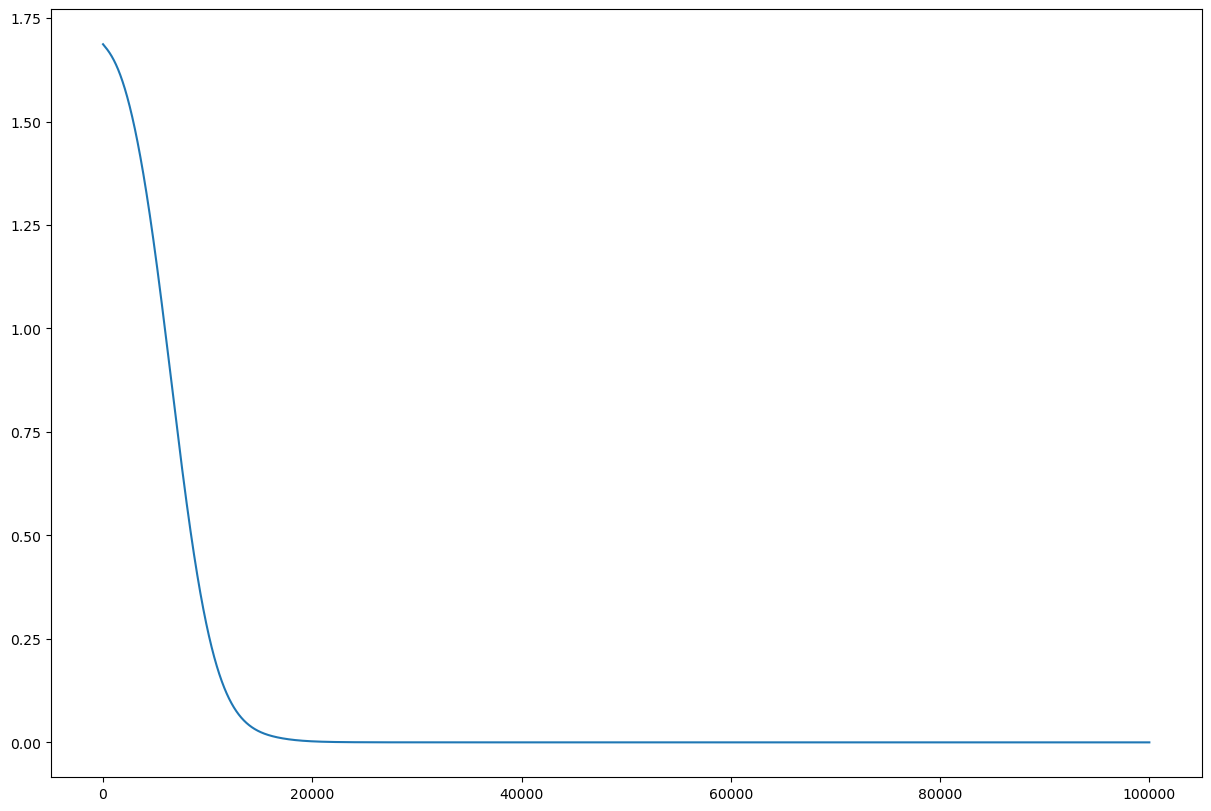

In [7]:
v1 =np.array(S_l)
v2 =np.array(V_l)
v3 =np.array(E_l)
v4 =np.array(I1_l)
v5 =np.array(I2_l)
v6 =np.array(I3_l)
v7 =np.array(R_l)
v8 =np.array(D_l)

S_pred_m =np.mean(v1, axis=0)
V_pred_m =np.mean(v2, axis=0)
E_pred_m =np.mean(v3, axis=0)
I1_pred_m =np.mean(v4, axis=0)
I2_pred_m =np.mean(v5, axis=0)
I3_pred_m =np.mean(v6, axis=0)
R_pred_m =np.mean(v7, axis=0)
D_pred_m =np.mean(v8, axis=0)


alpha_v1 = model.sess.run(model.alpha)
sigma_v1 = model.sess.run(model.sigma)
beta1_v1 = model.sess.run(model.beta1)
beta2_v1 = model.sess.run(model.beta2)
beta3_v1 = model.sess.run(model.beta3)
delta1_v1= model.sess.run(model.delta1)
delta2_v1 = model.sess.run(model.delta2)
delta3_v1 = model.sess.run(model.delta3)
mu_v1 = model.sess.run(model.mu)
gamma_v1 = model.sess.run(model.gamma)
p1_v1 = model.sess.run(model.p1)
p2_v1 = model.sess.run(model.p2)
sigma1_v1 = model.sess.run(model.sigma1)
sigma2_v1 = model.sess.run(model.sigma2)
sigma3_v1 = model.sess.run(model.sigma3)
sigma4_v1 = model.sess.run(model.sigma4)
sigma5_v1 = model.sess.run(model.sigma5)
sigma6_v1 = model.sess.run(model.sigma6)
sigma7_v1 = model.sess.run(model.sigma7)
sigma8_v1 = model.sess.run(model.sigma8)


alpha = round(alpha_v1, 5)
sigma = round(sigma_v1, 5)
beta1 = round(beta1_v1, 5)
beta2 = round(beta2_v1, 5)
beta3 = round(beta3_v1, 5)
delta1 = round(delta1_v1, 5)
delta2 = round(delta2_v1, 5)
delta3 = round(delta3_v1, 5)
mu = round(mu_v1, 5)
gamma = round(gamma_v1, 5)
p1 = round(p1_v1, 5)
p2 = round(p2_v1, 5)
sigma1 = round(sigma1_v1, 5)
sigma2 = round(sigma2_v1, 5)
sigma3 = round(sigma3_v1, 5)
sigma4 = round(sigma4_v1, 5)
sigma5 = round(sigma5_v1, 5)
sigma6 = round(sigma6_v1, 5)
sigma7 = round(sigma7_v1, 5)
sigma8 = round(sigma8_v1, 5)

fig2, ax2 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax2.plot(total_loss)

Calibrated Parameter Results

In [8]:
print('alpha', alpha)
print('sigma',sigma) 
print('beta1',beta1) 
print('beta2',beta2)
print('beta3',beta3)
print('delta1',delta1)
print('delta2',delta2)
print('delta3',delta3)
print('mu',mu)
print('gamma',gamma)
print('p1',p1)
print('p2',p2)
print('sigma1 S',sigma1) 
print('sigma2 V',sigma2)
print('sigma3 E',sigma3)
print('sigma4 I1',sigma4)
print('sigma5 I2',sigma5)
print('sigma6 I3',sigma6)
print('sigma7 R',sigma7)
print('sigma8 D',sigma8)

alpha 0.00135
sigma 0.06352
beta1 0.2812
beta2 0.15838
beta3 0.0388
delta1 0.28505
delta2 0.28269
delta3 0.14206
mu 0.0042
gamma 0.30954
p1 0.01845
p2 0.1431
sigma1 S 0.09275
sigma2 V 0.03887
sigma3 E 0.07517
sigma4 I1 0.06302
sigma5 I2 0.07878
sigma6 I3 0.06123
sigma7 R 0.0611
sigma8 D 0.06199


Error matrix
- RMSE
- MAPE

In [9]:
##Calculate the error metrics for stochastic for Infected
S_test_pred = S_pred_m.reshape(-1,) 
S_test_actual = SS.reshape(-1,)

S_rmse =np.sqrt(mean_squared_error(S_test_actual, S_test_pred))
S_mape =np.linalg.norm((S_test_pred-S_test_actual),2)/np.linalg.norm(S_test_actual, 2)   

print('S_RMSE',S_rmse)
print('S_MAPE',S_mape)

V_test_pred = V_pred_m.reshape(-1,) 
V_test_actual = VV.reshape(-1,)

V_rmse =np.sqrt(mean_squared_error(V_test_actual, V_test_pred))
V_mape =np.linalg.norm((V_test_pred-V_test_actual),2)/np.linalg.norm(V_test_actual, 2)   

print('V_RMSE',V_rmse)
print('V_MAPE',V_mape)

E_test_pred = E_pred_m.reshape(-1,) 
E_test_actual = EE.reshape(-1,)

E_rmse =np.sqrt(mean_squared_error(E_test_actual, E_test_pred))
E_mape =np.linalg.norm((E_test_pred - E_test_actual),2)/np.linalg.norm(E_test_actual, 2)   

print('E_RMSE',E_rmse)
print('E_MAPE',E_mape)

I1_test_pred = I1_pred_m.reshape(-1,) 
I1_test_actual = I1I.reshape(-1,)

I1_rmse =np.sqrt(mean_squared_error(I1_test_actual, I1_test_pred))
I1_mape =np.linalg.norm((I1_test_pred-I1_test_actual),2)/np.linalg.norm(I1_test_actual, 2)   

print('I1_RMSE',I1_rmse)
print('I1_MAPE',I1_mape)

I2_test_pred = I2_pred_m.reshape(-1,) 
I2_test_actual = I2I.reshape(-1,)

I2_rmse =np.sqrt(mean_squared_error(I2_test_actual, I2_test_pred))
I2_mape =np.linalg.norm((I2_test_pred-I2_test_actual),2)/np.linalg.norm(I2_test_actual, 2)   

print('I2_RMSE',I2_rmse)
print('I2_MAPE',I2_mape)

I3_test_pred = I3_pred_m.reshape(-1,) 
I3_test_actual = I3I.reshape(-1,)

I3_rmse =np.sqrt(mean_squared_error(I3_test_actual, I3_test_pred))
I3_mape =np.linalg.norm((I3_test_pred-I3_test_actual),2)/np.linalg.norm(I3_test_actual, 2)   

print('I3_RMSE',I3_rmse)
print('I3_MAPE',I3_mape)

R_test_pred = R_pred_m.reshape(-1,) 
R_test_actual = RR.reshape(-1,)

R_rmse =np.sqrt(mean_squared_error(R_test_actual, R_test_pred))
R_mape =np.linalg.norm((R_test_pred - R_test_actual),2)/np.linalg.norm(R_test_actual, 2)   

print('R_RMSE', R_rmse)
print('R_MAPE', R_mape)

D_test_pred = D_pred_m.reshape(-1,) 
D_test_actual = DD.reshape(-1,)

D_rmse =np.sqrt(mean_squared_error(D_test_actual, D_test_pred))
D_mape =np.linalg.norm((D_test_pred-D_test_actual),2)/np.linalg.norm(D_test_actual, 2)   

print('D_RMSE',D_rmse)
print('D_MAPE',D_mape)

total_rmse = S_rmse + V_rmse + E_rmse + I1_rmse + I2_rmse + I3_rmse + R_rmse + D_rmse
total_mape = S_mape + V_mape + E_mape + I1_mape + I2_mape + I3_mape + R_mape + D_mape
print('TOTAL_RMSE', total_rmse)
print('TOTAL_MAPE', total_mape)

S_RMSE 0.0012326001362117514
S_MAPE 0.006745293039010713
V_RMSE 0.00017440730595815317
V_MAPE 0.00022174383597795743
E_RMSE 0.0020744761693751437
E_MAPE 0.19269769572359058
I1_RMSE 0.00020678468430647716
I1_MAPE 0.107843880685072
I2_RMSE 8.404733623998356e-05
I2_MAPE 1.6013137510462303
I3_RMSE 8.141604285113473e-05
I3_MAPE 7.876853981808644
R_RMSE 0.00017566836643443558
R_MAPE 0.009366664320522758
D_RMSE 0.00015520182659382916
D_MAPE 0.7188409489417018
TOTAL_RMSE 0.004184601867970908
TOTAL_MAPE 10.51388395940075


In [10]:
st ='2021-12-03'
ed ='2021-12-23'
date_begin = dt.date(2021, 12, 3)
date_end = date_begin + dt.timedelta(days=ub) 
delt = dt.timedelta(days = ub/npoints)
dates = mpl.dates.drange(date_begin, date_end, delt)

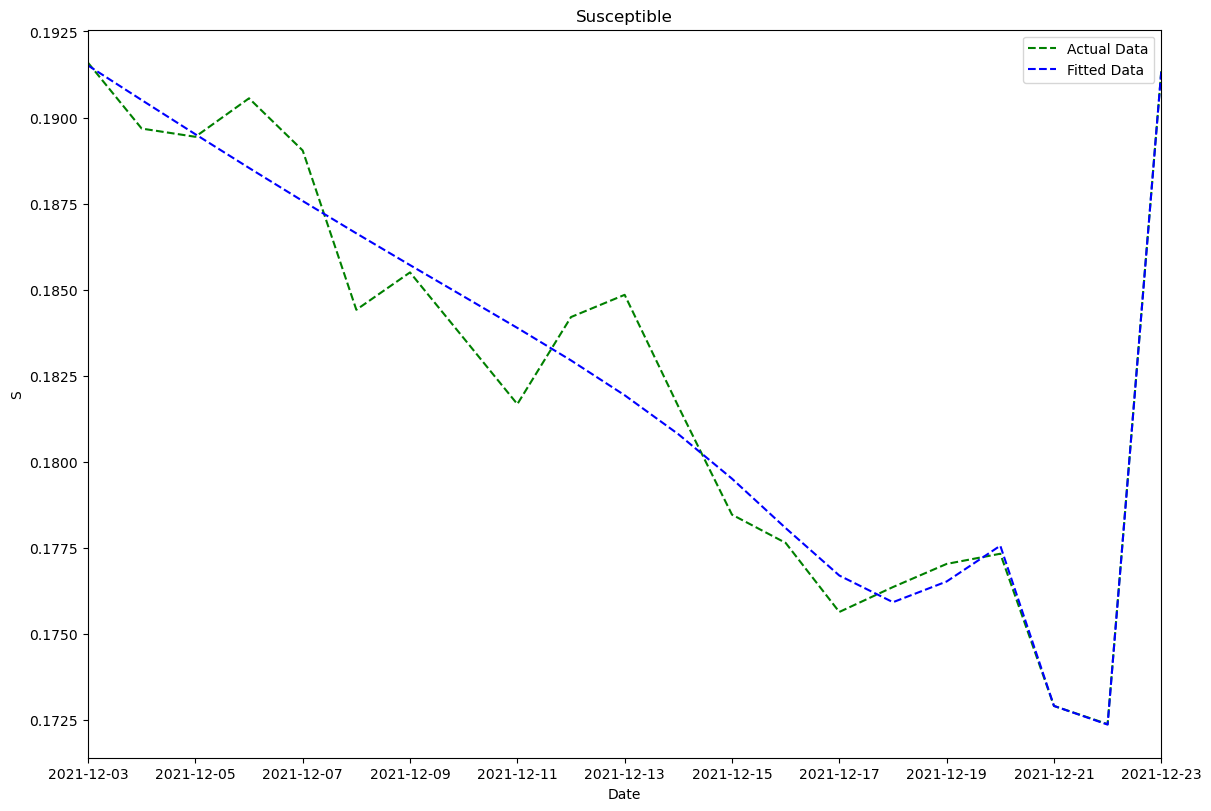

In [11]:
lims = (np.datetime64(st), np.datetime64(ed))

fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,SS, '--g')
ax1.plot(dates,S_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('S')
ax1.set_title('Susceptible')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])
# ax1[0].grid(axis='y')

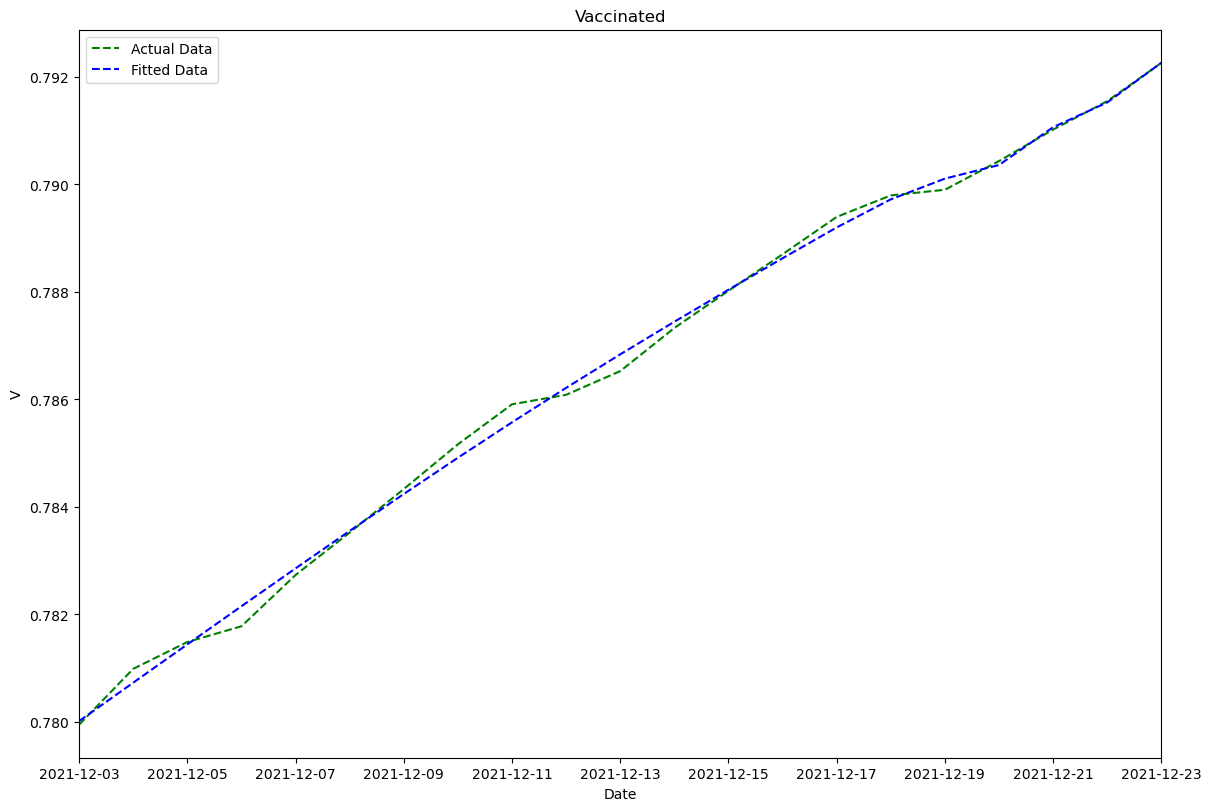

In [12]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,VV, '--g')
ax1.plot(dates,V_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('V')
ax1.set_title('Vaccinated')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

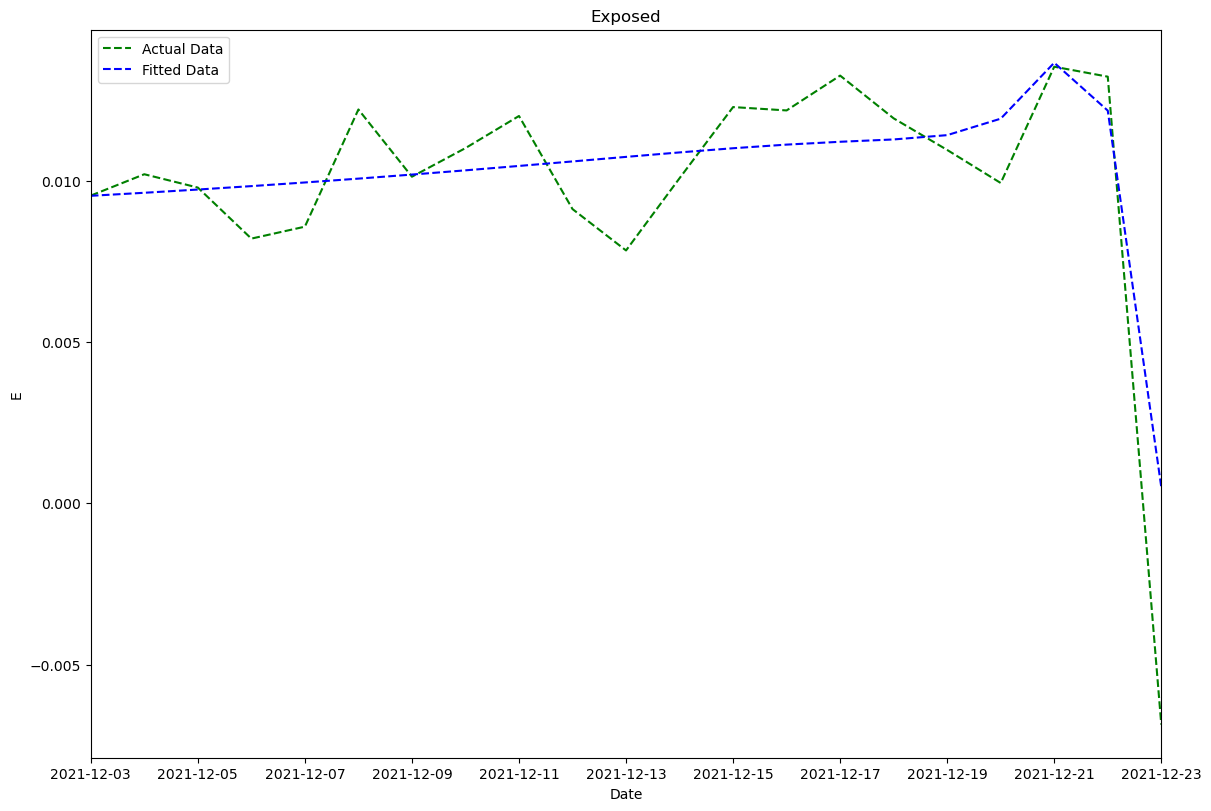

In [13]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,EE, '--g')
ax1.plot(dates,E_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('E')
ax1.set_title('Exposed')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

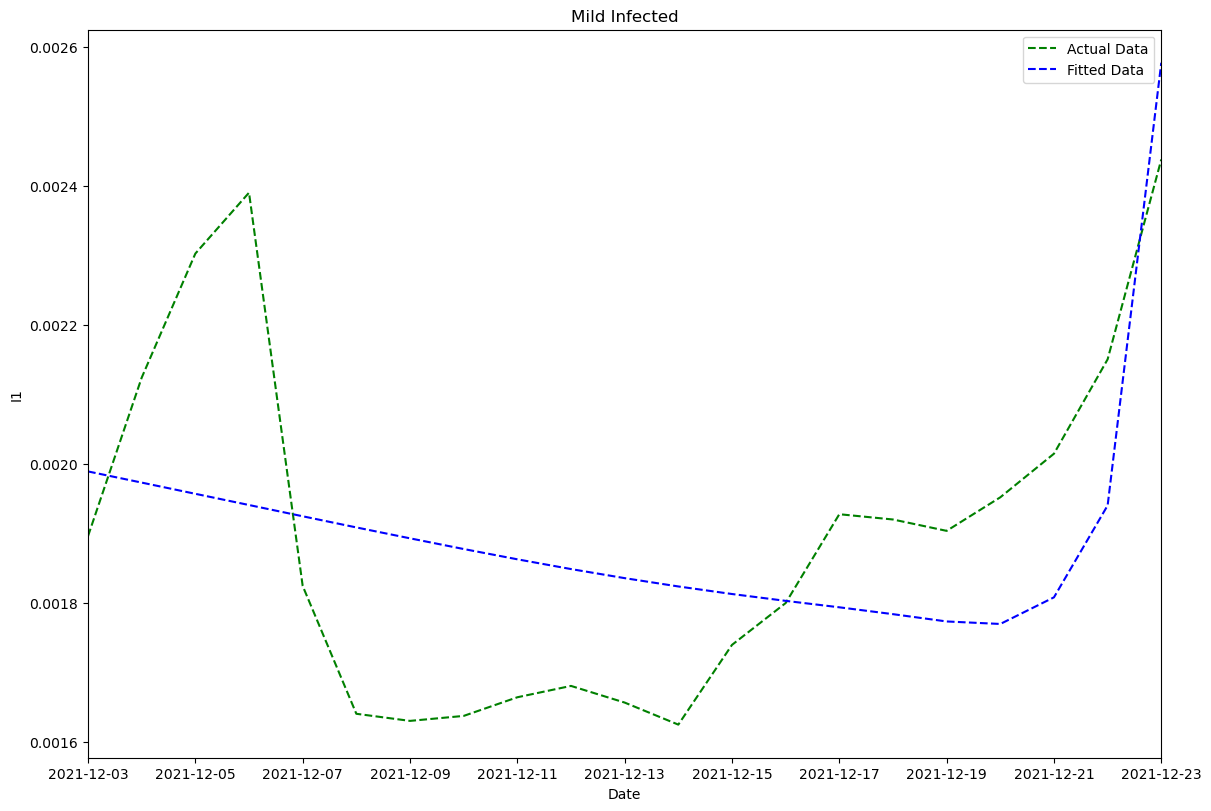

In [14]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,I1I, '--g')

ax1.plot(dates,I1_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('I1')
ax1.set_title('Mild Infected')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

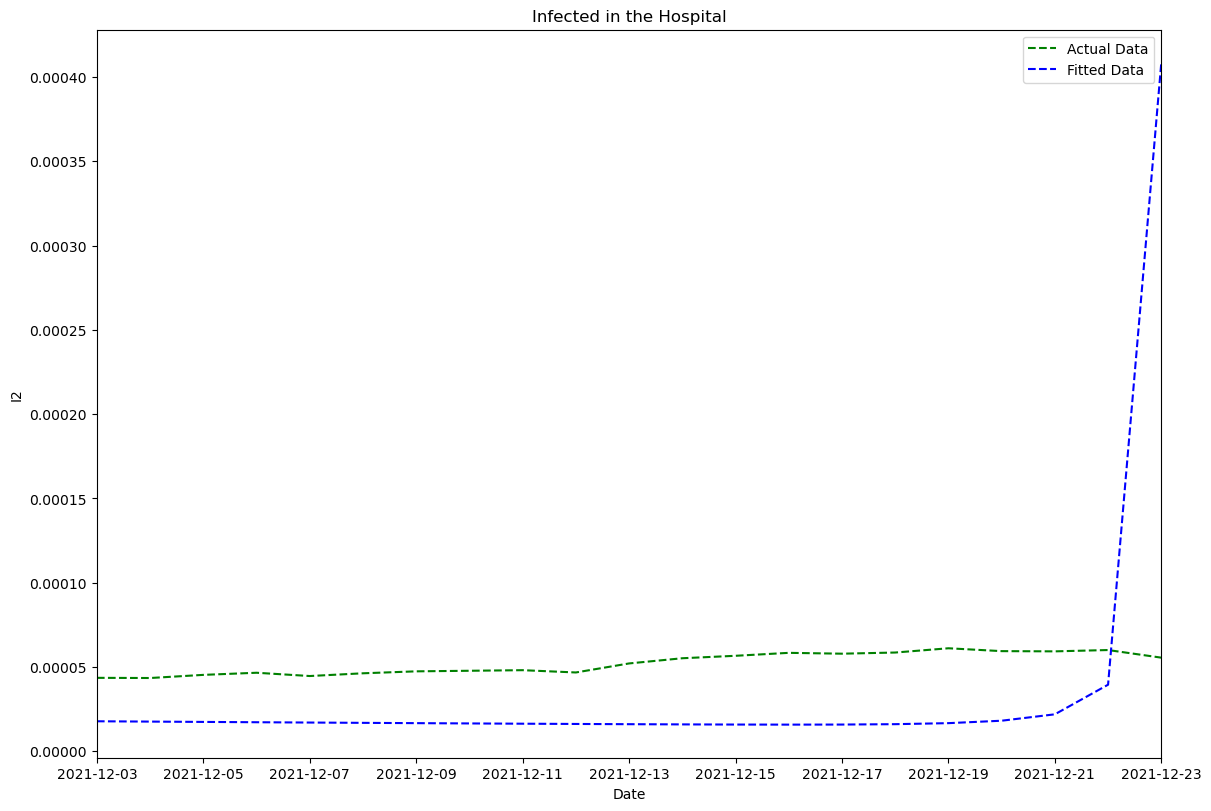

In [15]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,I2I, '--g')
ax1.plot(dates,I2_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('I2')
ax1.set_title('Infected in the Hospital')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

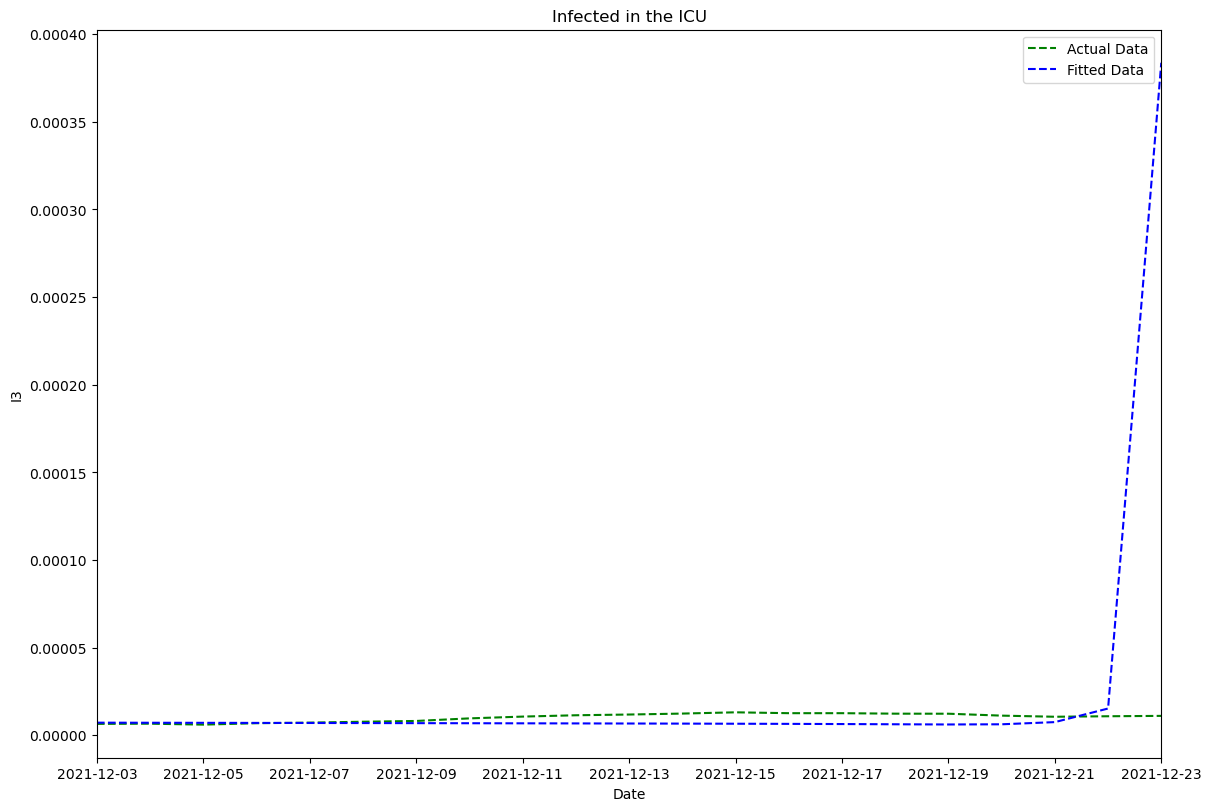

In [16]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,I3I, '--g')
ax1.plot(dates,I3_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('I3')
ax1.set_title('Infected in the ICU')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

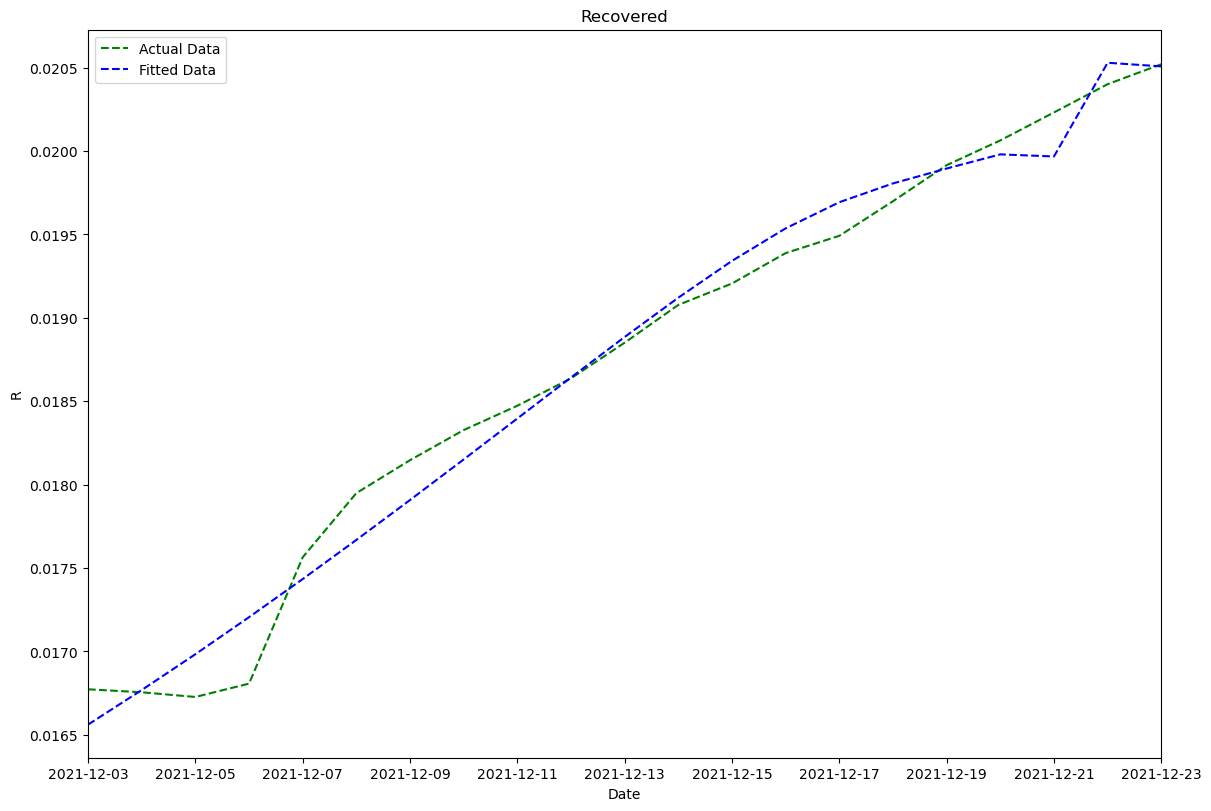

In [17]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,RR, '--g')
ax1.plot(dates,R_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('R')
ax1.set_title('Recovered')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

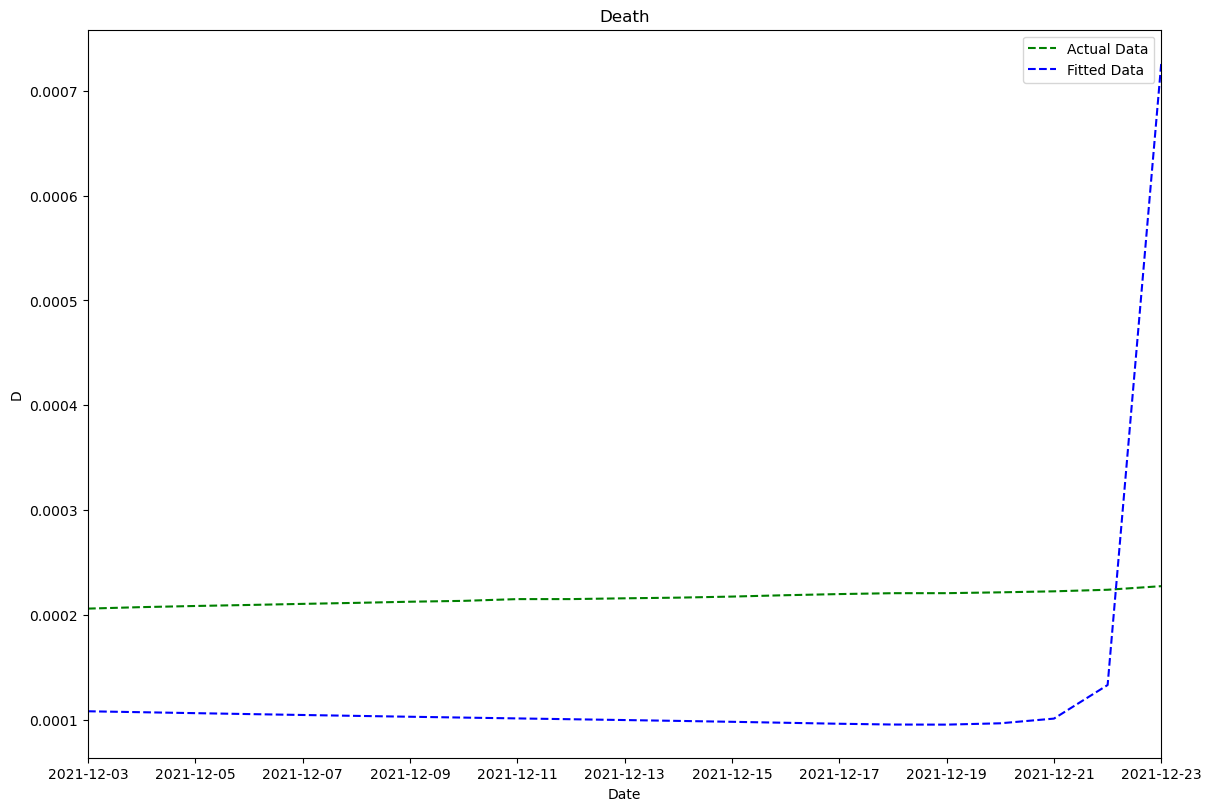

In [18]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,DD, '--g')
ax1.plot(dates,D_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('D')
ax1.set_title('Death')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

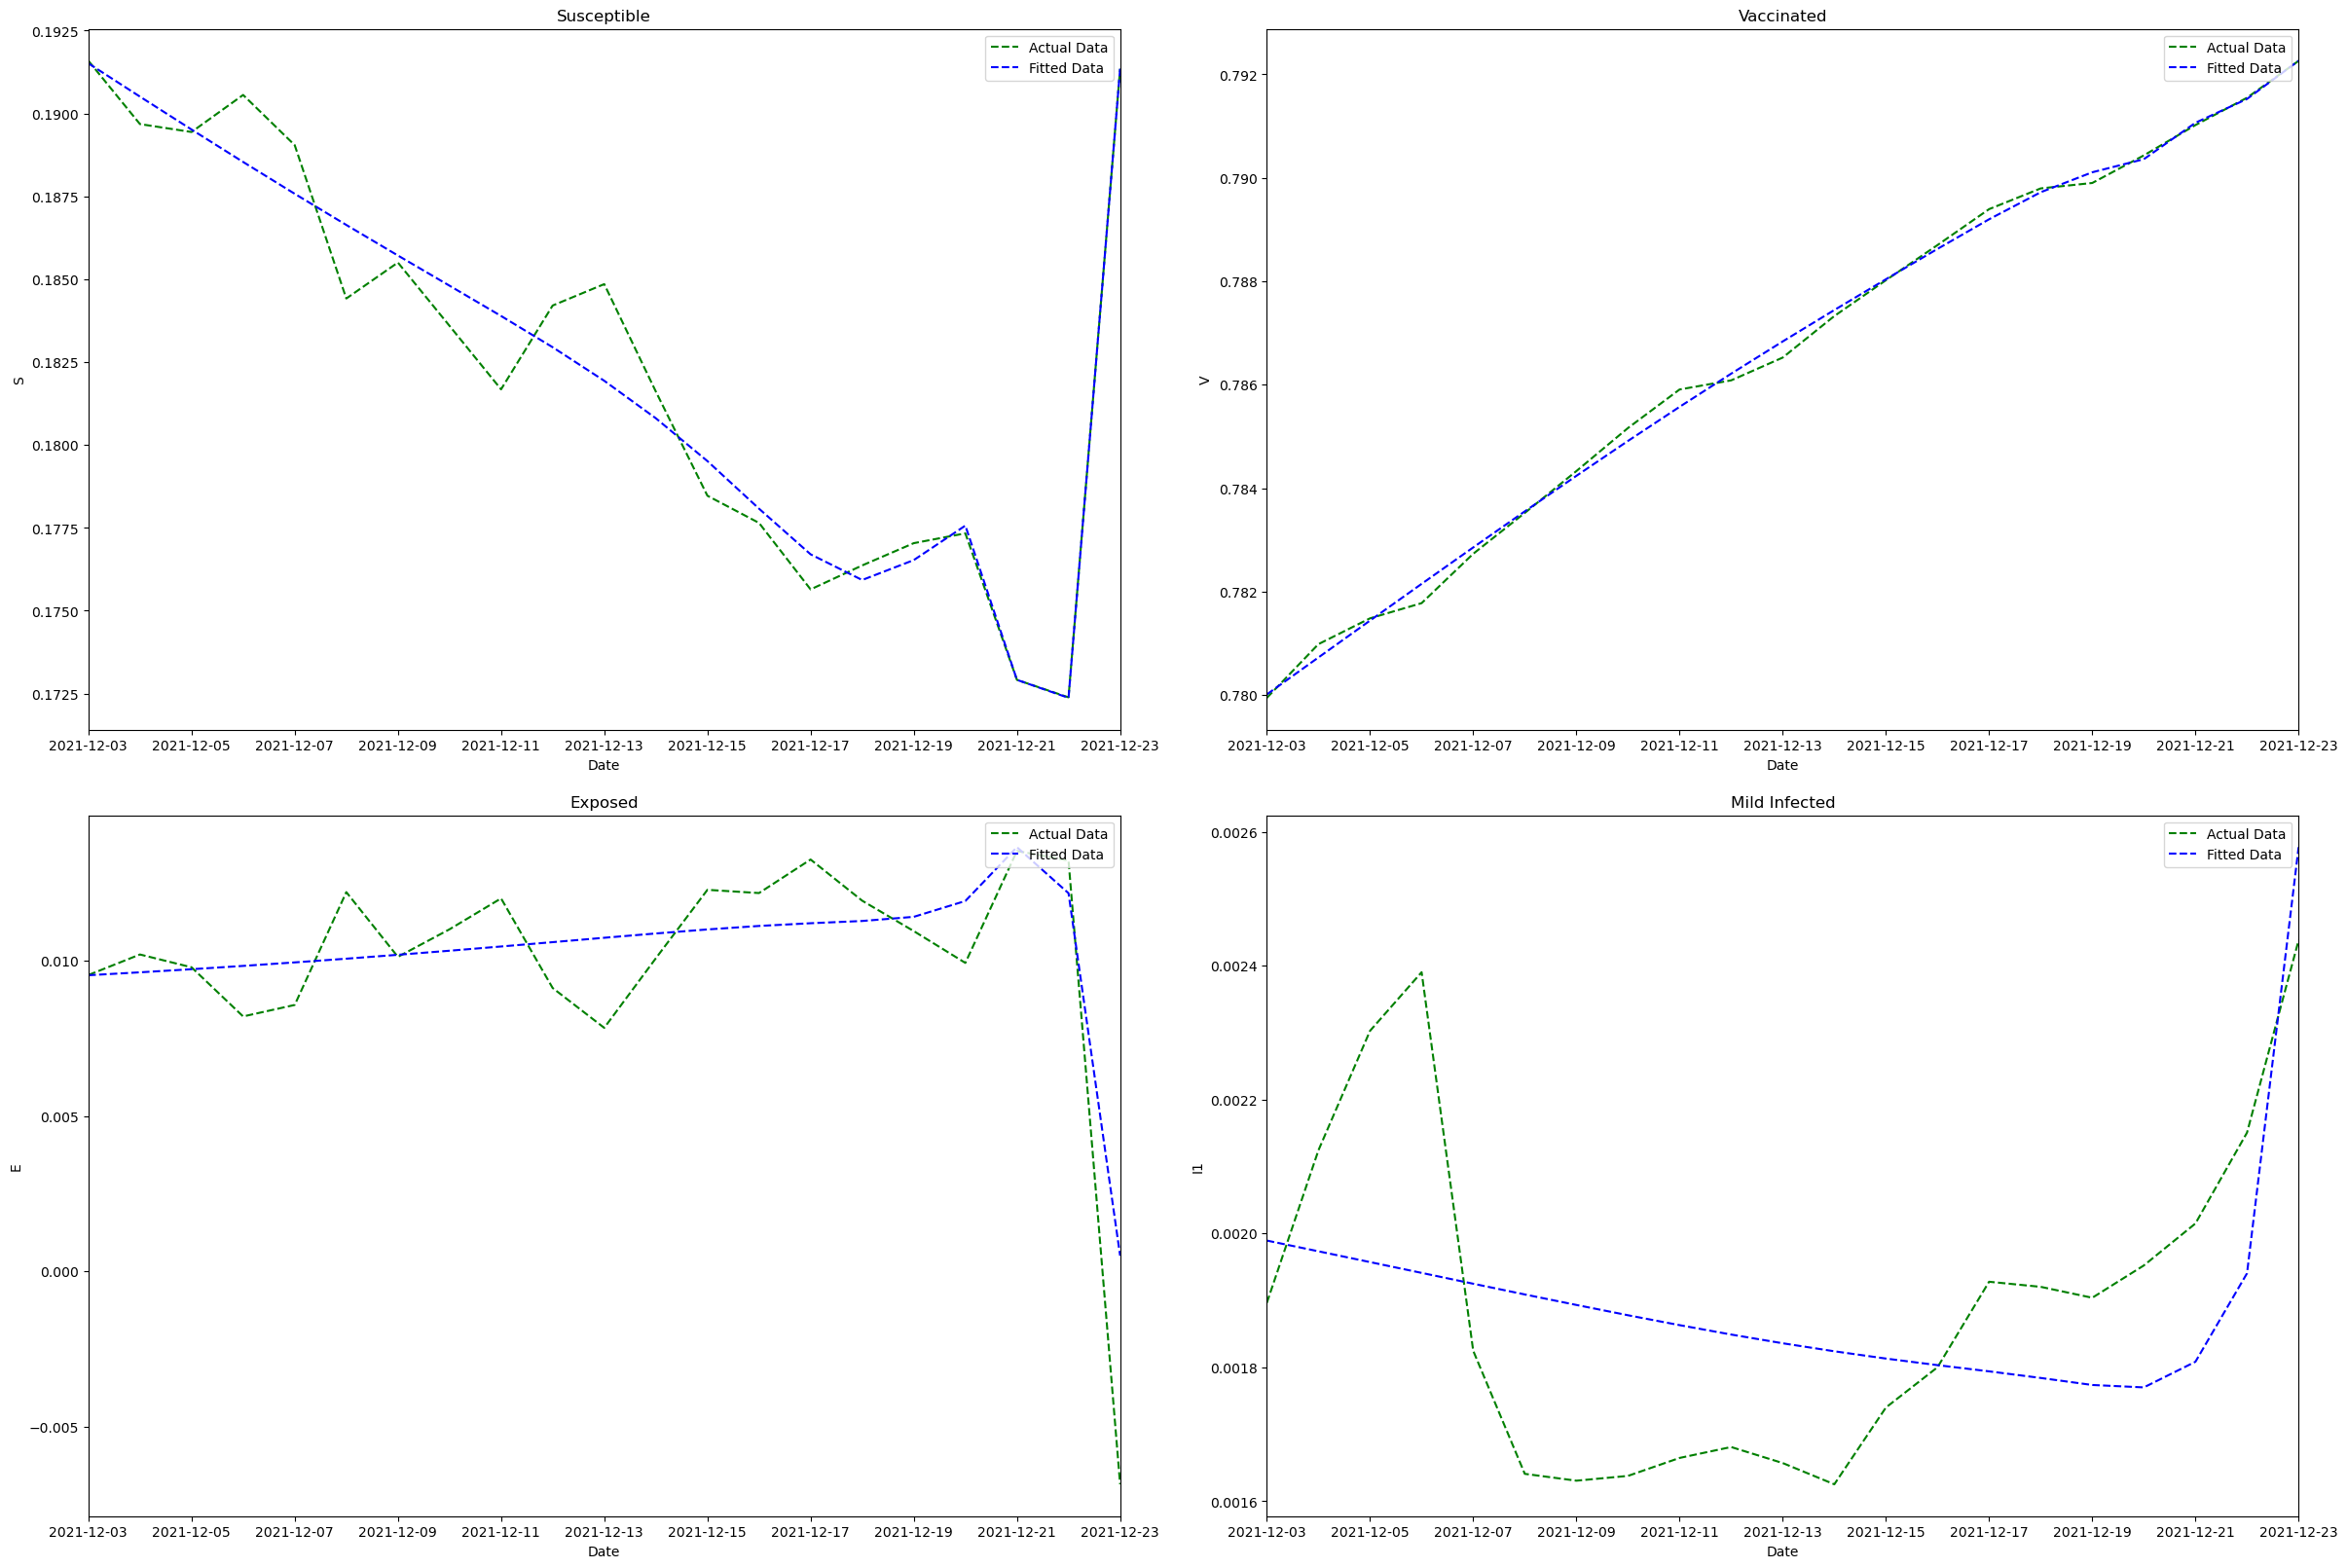

In [19]:
# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, constrained_layout=True, figsize=(24, 16))

# Custom plots for each subplot
def plot_1(ax):
    ax.plot(dates,SS, '--g')
    ax.plot(dates,S_pred_m.flatten().tolist(), '--b')
    ax.set_xlabel('Date')
    ax.set_ylabel('S')
    ax.set_title('Susceptible')
    ax.set_xlim(lims)
    ax.legend(['Actual Data',r'Fitted Data'], loc='upper right')


def plot_2(ax):
    ax.plot(dates,VV, '--g')
    ax.plot(dates,V_pred_m.flatten().tolist(), '--b')
    ax.set_xlabel('Date')
    ax.set_ylabel('V')
    ax.set_title('Vaccinated')
    ax.set_xlim(lims)
    ax.legend(['Actual Data',r'Fitted Data'], loc='upper right')


def plot_3(ax):
    ax.plot(dates,EE, '--g')
    ax.plot(dates,E_pred_m.flatten().tolist(), '--b')
    ax.set_xlabel('Date')
    ax.set_ylabel('E')
    ax.set_title('Exposed')
    ax.set_xlim(lims)
    ax.legend(['Actual Data',r'Fitted Data'], loc='upper right')


def plot_4(ax):
    ax.plot(dates,I1I, '--g')
    ax.plot(dates,I1_pred_m.flatten().tolist(), '--b')
    ax.set_xlabel('Date')
    ax.set_ylabel('I1')
    ax.set_title('Mild Infected')
    ax.set_xlim(lims)
    ax.legend(['Actual Data',r'Fitted Data'], loc='upper right')


# Apply different plots to each subplot
plot_1(axs[0, 0])
plot_2(axs[0, 1])
plot_3(axs[1, 0])
plot_4(axs[1, 1])

# Set common labels 
for ax in axs.flat:
    ax.set_xlabel('Date')


# Display the plot
# plt.show()
plt.savefig('sto_test_data_fitting_'+str(POINTS)+'xpoints_'+str(GRID)+'0%grid_seed'+str(SEED)+'.png')

In [20]:
print('TOTAL_RMSE', total_rmse)
print('TOTAL_MAPE', total_mape)

TOTAL_RMSE 0.004184601867970908
TOTAL_MAPE 10.51388395940075


alpha 0.00135
sigma 0.06352
beta1 0.2812
beta2 0.15838
beta3 0.0388
delta1 0.28505
delta2 0.28269
delta3 0.14206
gamma 0.30954
p1 0.01845
p2 0.1431
mu 0.0042
sigma1 0.09275
sigma2 0.03887
sigma3 0.07517
sigma4 0.06302
sigma5 0.07878
sigma6 0.06123
sigma7 0.0611
sigma8 0.06199


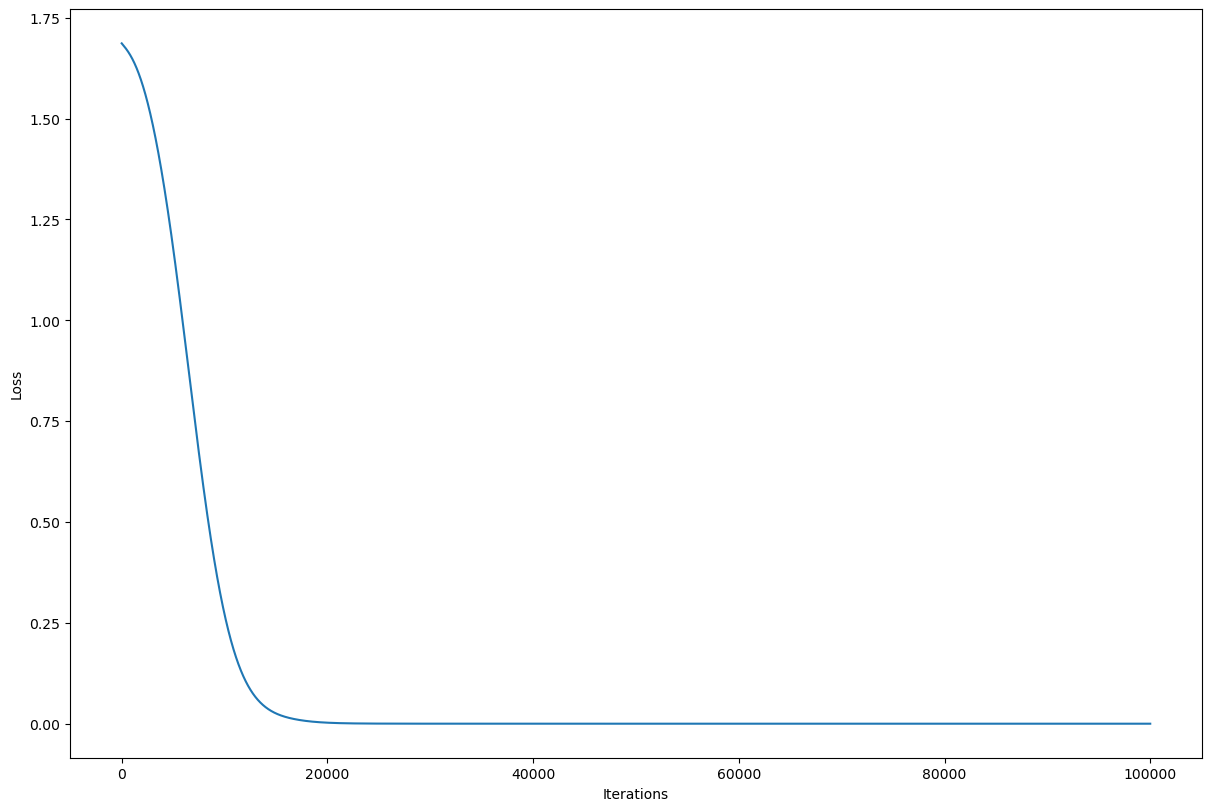

In [21]:
print('alpha', alpha)
print('sigma',sigma) 
print('beta1',beta1) 
print('beta2',beta2)
print('beta3',beta3)
print('delta1',delta1)
print('delta2',delta2)
print('delta3',delta3)
print('gamma',gamma)
print('p1',p1)
print('p2',p2)
print('mu',mu)
print('sigma1',sigma1) 
print('sigma2',sigma2)
print('sigma3',sigma3)
print('sigma4',sigma4)
print('sigma5',sigma5)
print('sigma6',sigma6)
print('sigma7',sigma7)
print('sigma8',sigma8)

fig2, ax2 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax2.plot(total_loss)
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Loss')
plt.savefig('sto_test_loss_'+str(POINTS)+'xpoints_'+str(GRID)+'0%grid_seed'+str(SEED)+'.png')

# validation

RUNNING STABLE EULER-MARUYAMA SDE SIMULATIONS
Running 1000 MC simulations...
  Observation points: 21
  dt between obs: 1.0500
  Sub-steps: 20
  Actual dt: 0.052500
  Progress: 200/1000
  Progress: 400/1000
  Progress: 600/1000
  Progress: 800/1000
  Progress: 1000/1000
Simulation complete!

Creating validation figure...
Figure saved: FigS1_PINN_validation_stable.png


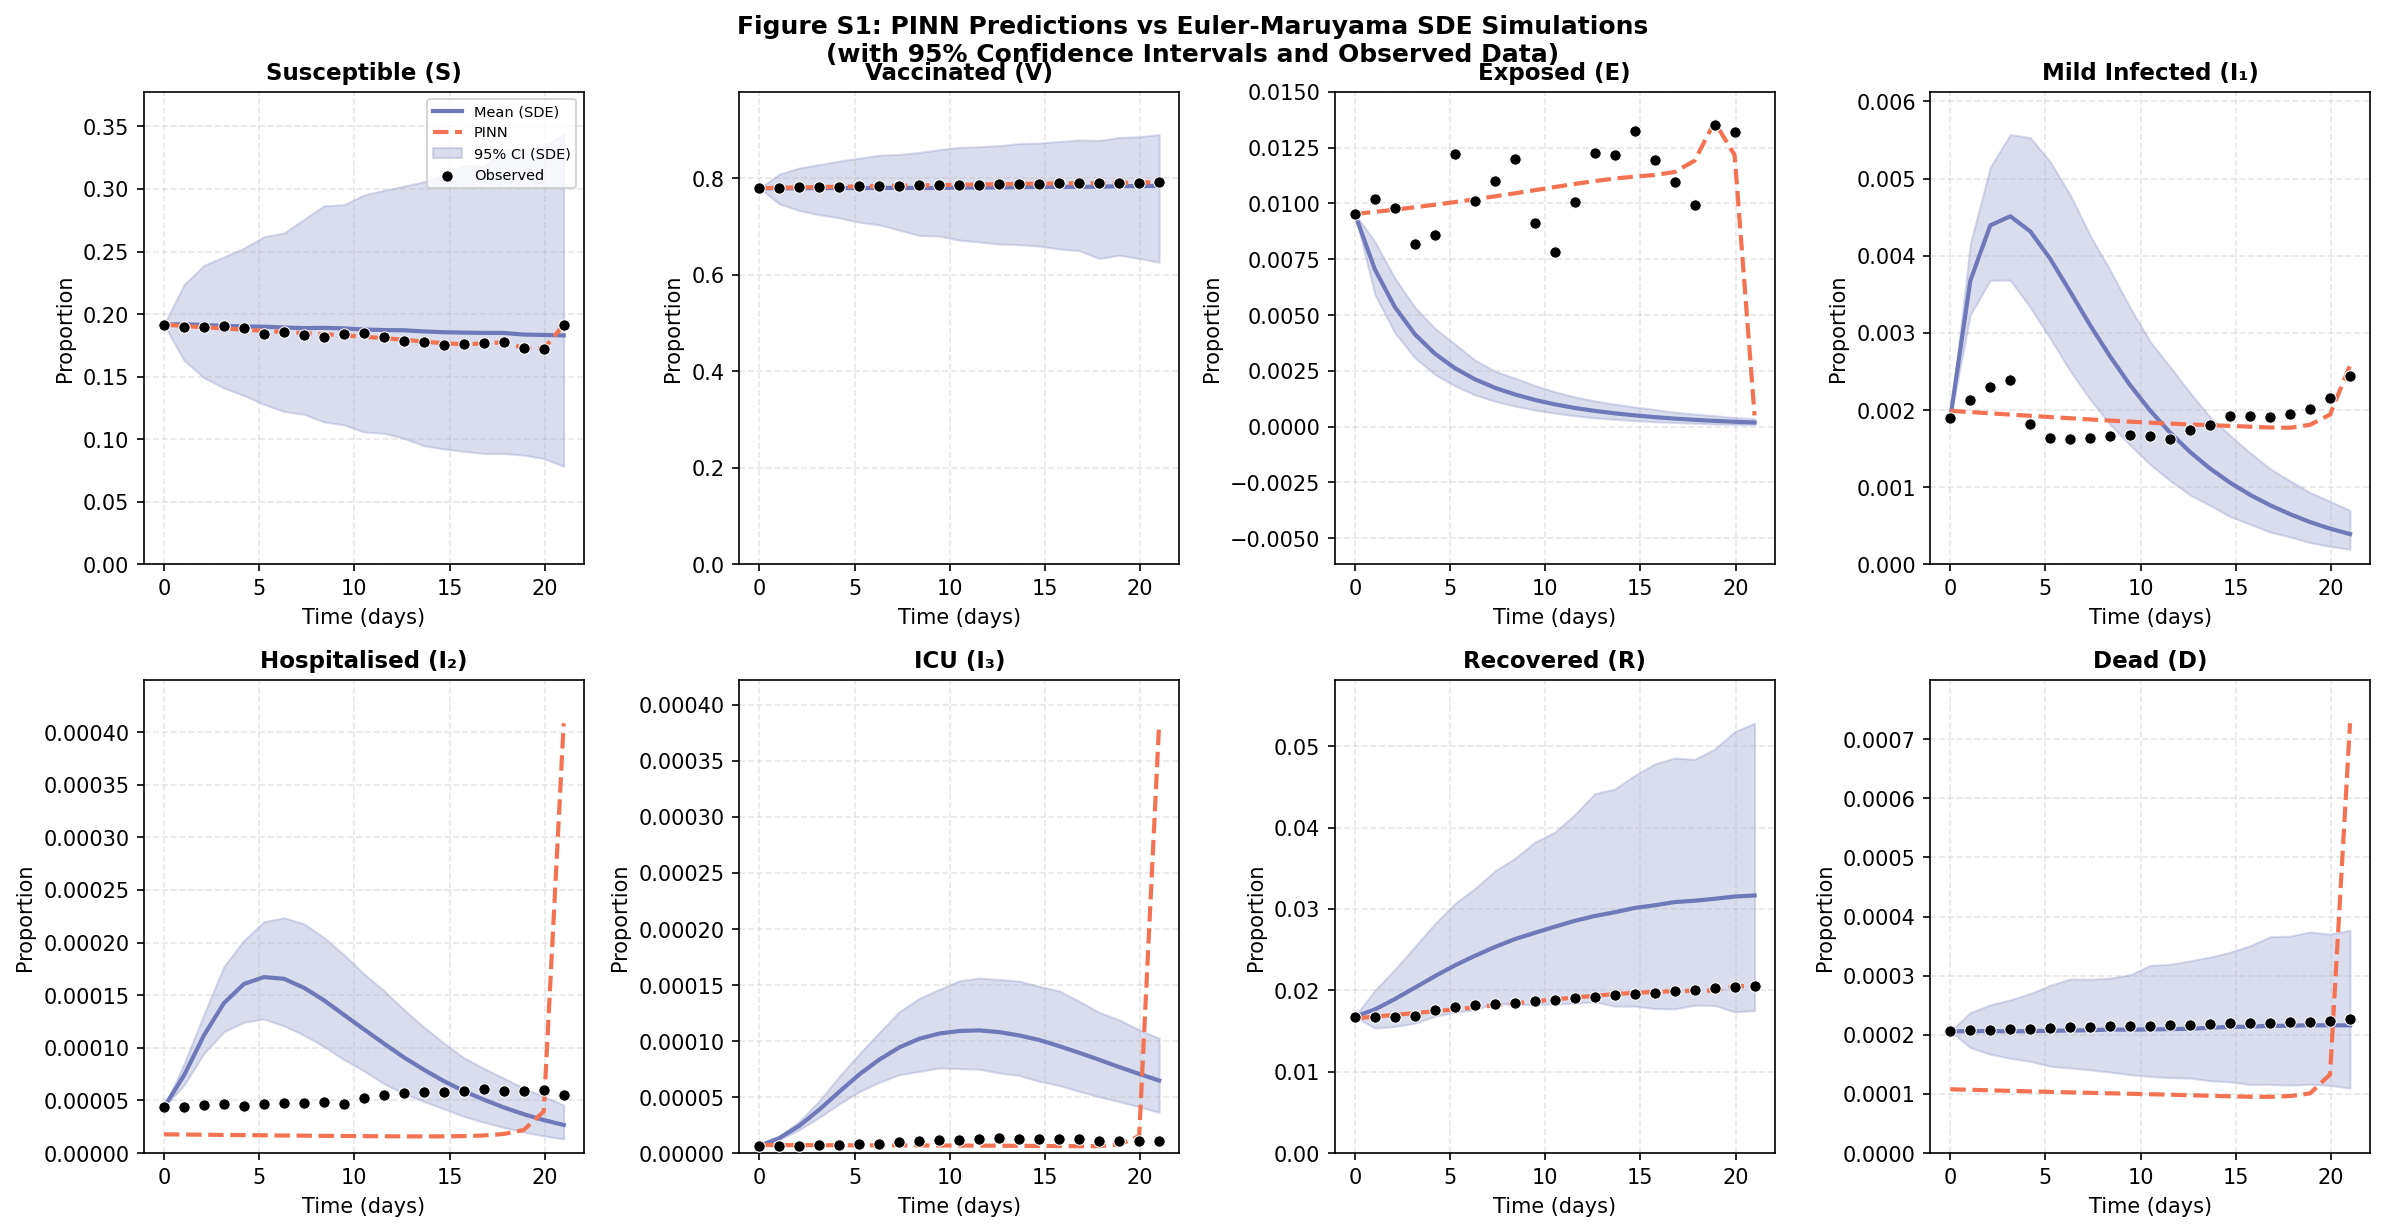


VALIDATION METRICS

1. RMSE (PINN vs SDE Mean):
--------------------------------------------------
   S: 0.00656627
   V: 0.00562157
   E: 0.00897001
   I1: 0.00143223
   I2: 0.00012413
   I3: 0.00010250
   R: 0.00842164
   D: 0.00015335

2. RMSE (PINN vs Observed):
--------------------------------------------------
   S: 0.00123260
   V: 0.00017441
   E: 0.00207448
   I1: 0.00020678
   I2: 0.00008405
   I3: 0.00008142
   R: 0.00017567
   D: 0.00015520

3. Coverage (Observed data within 95% CI):
--------------------------------------------------
   S: 95.2%
   V: 95.2%
   E: 0.0%
   I1: 23.8%
   I2: 33.3%
   I3: 0.0%
   R: 90.5%
   D: 95.2%

4. Coverage (PINN predictions within 95% CI):
--------------------------------------------------
   S: 95.2%
   V: 95.2%
   E: 0.0%
   I1: 28.6%
   I2: 9.5%
   I3: 0.0%
   R: 90.5%
   D: 4.8%

5. Sanity Check (values should be in [0,1]):
--------------------------------------------------
   S: CI range [0.0784, 0.3436]
   V: CI range [0.6264, 0.89

In [22]:
# =============================================================================
# CORRECTED PINN VALIDATION CODE - Stable Euler-Maruyama
# =============================================================================
# Key fixes:
# 1. Sub-stepping for numerical stability (smaller dt)
# 2. Normalization to ensure proportions sum to 1
# 3. Clamping to keep values in [0, 1]
# 4. Proper handling of stochastic volatility
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

def euler_maruyama_svei3rd_stable(X0, t_span, params, n_mc=1000, seed=123, 
                                   substeps=10, normalize=True):
    """
    STABLE Euler-Maruyama simulation for stochastic SVEI3RD model.
    
    Key improvements over naive implementation:
    1. Sub-stepping: Divides each observation interval into smaller steps
    2. Normalization: Ensures S+V+E+I1+I2+I3+R+D = 1 after each step
    3. Clamping: Keeps all values in [0, 1] range
    
    Parameters:
    -----------
    X0 : list - Initial conditions [S, V, E, I1, I2, I3, R, D]
    t_span : array - Observation time points
    params : dict - Model parameters
    n_mc : int - Number of Monte Carlo simulations
    seed : int - Random seed
    substeps : int - Number of sub-steps between each observation point
    normalize : bool - Whether to normalize proportions after each step
    
    Returns:
    --------
    mean_traj, ci_lower, ci_upper, trajectories
    """
    np.random.seed(seed)
    
    n_obs = len(t_span)
    
    # Compute dt between observations
    if n_obs > 1:
        dt_obs = t_span[1] - t_span[0]
    else:
        dt_obs = 1.0
    
    # Sub-step dt for stability
    dt = dt_obs / substeps
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    trajectories = {comp: np.zeros((n_mc, n_obs)) for comp in compartments}
    
    print(f"Running {n_mc} MC simulations...")
    print(f"  Observation points: {n_obs}")
    print(f"  dt between obs: {dt_obs:.4f}")
    print(f"  Sub-steps: {substeps}")
    print(f"  Actual dt: {dt:.6f}")
    
    for mc in range(n_mc):
        if (mc + 1) % 200 == 0:
            print(f"  Progress: {mc+1}/{n_mc}")
        
        # Initialize state
        state = np.array(X0, dtype=np.float64)
        
        # Normalize initial conditions
        if normalize:
            state = state / np.sum(state)
        
        # Store initial
        for i, comp in enumerate(compartments):
            trajectories[comp][mc, 0] = state[i]
        
        # Simulate
        for obs_idx in range(1, n_obs):
            # Sub-stepping between observation points
            for _ in range(substeps):
                S, V, E, I1, I2, I3, R, D = state
                
                # Brownian increments (scaled by sqrt(dt))
                dW = np.random.normal(0, np.sqrt(dt), 8)
                
                # Force of infection
                foi = params['beta1'] * I1 + params['beta2'] * I2 + params['beta3'] * I3
                
                # Drift terms (deterministic part of SDE)
                drift = np.array([
                    params['birth'] - foi * S - params['alpha'] * S - params['death'] * S,
                    params['alpha'] * S - params['sigma'] * foi * V - params['death'] * V,
                    foi * (S + params['sigma'] * V) - params['gamma'] * E - params['death'] * E,
                    params['gamma'] * E - (params['delta1'] + params['p1']) * I1 - params['death'] * I1,
                    params['p1'] * I1 - (params['delta2'] + params['p2']) * I2 - params['death'] * I2,
                    params['p2'] * I2 - (params['delta3'] + params['mu']) * I3 - params['death'] * I3,
                    params['delta1'] * I1 + params['delta2'] * I2 + params['delta3'] * I3 - params['death'] * R,
                    params['mu'] * I3
                ])
                
                # Diffusion terms (stochastic part)
                # Using multiplicative noise: σ_i * X_i * dW_i
                diffusion = np.array([
                    params['sigma1'] * S * dW[0],
                    params['sigma2'] * V * dW[1],
                    params['sigma3'] * E * dW[2],
                    params['sigma4'] * I1 * dW[3],
                    params['sigma5'] * I2 * dW[4],
                    params['sigma6'] * I3 * dW[5],
                    params['sigma7'] * R * dW[6],
                    params['sigma8'] * D * dW[7]
                ])
                
                # Euler-Maruyama update
                state = state + drift * dt + diffusion
                
                # Clamp to non-negative values
                state = np.maximum(state, 0.0)
                
                # Normalize to ensure sum = 1 (since these are proportions)
                if normalize:
                    total = np.sum(state)
                    if total > 0:
                        state = state / total
            
            # Store at observation point
            for i, comp in enumerate(compartments):
                trajectories[comp][mc, obs_idx] = state[i]
    
    # Compute statistics
    mean_traj = {k: np.mean(v, axis=0) for k, v in trajectories.items()}
    ci_lower = {k: np.percentile(v, 2.5, axis=0) for k, v in trajectories.items()}
    ci_upper = {k: np.percentile(v, 97.5, axis=0) for k, v in trajectories.items()}
    std_traj = {k: np.std(v, axis=0) for k, v in trajectories.items()}
    
    print("Simulation complete!")
    
    return mean_traj, ci_lower, ci_upper, trajectories, std_traj


def create_validation_figure_improved(observed, pinn_pred, mean_sde, ci_lower, ci_upper, 
                                       t_span, save_path=None):
    """
    Create publication-ready validation figure with improved styling.
    """
    # Custom colors
    new_purple = (111/255, 120/255, 185/255)
    new_red = (243/255, 114/255, 82/255)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=150)
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    titles = ['Susceptible (S)', 'Vaccinated (V)', 'Exposed (E)', 'Mild Infected (I₁)',
              'Hospitalised (I₂)', 'ICU (I₃)', 'Recovered (R)', 'Dead (D)']
    
    for idx, (ax, comp, title) in enumerate(zip(axes.flat, compartments, titles)):
        # 95% CI band
        ax.fill_between(t_span, ci_lower[comp], ci_upper[comp], 
                        alpha=0.25, color=new_purple, label='95% CI (SDE)')
        
        # Mean SDE trajectory
        ax.plot(t_span, mean_sde[comp], '-', color=new_purple, 
                linewidth=2, label='Mean (SDE)')
        
        # PINN prediction
        ax.plot(t_span, pinn_pred[comp], '--', color=new_red, 
                linewidth=2, label='PINN')
        
        # Observed data points (sample for visibility)
        n_obs = len(observed[comp])
        if n_obs > 40:
            step = max(1, n_obs // 25)
            obs_idx = np.arange(0, n_obs, step)
        else:
            obs_idx = np.arange(n_obs)
        
        ax.scatter(t_span[obs_idx], observed[comp][obs_idx], 
                   c='black', s=30, zorder=5, marker='o', 
                   label='Observed', edgecolors='white', linewidth=0.5)
        
        ax.set_xlabel('Time (days)', fontsize=10)
        ax.set_ylabel('Proportion', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set reasonable y-limits (proportions should be 0-1)
        ymin = min(0, np.min(observed[comp]) * 0.9)
        ymax = max(np.max(observed[comp]), np.max(pinn_pred[comp]), 
                   np.max(ci_upper[comp])) * 1.1
        ymax = min(ymax, 1.0)  # Cap at 1.0 for proportions
        ax.set_ylim(ymin, ymax)
        
        if idx == 0:
            ax.legend(loc='upper right', fontsize=7)
    
    plt.suptitle('Figure S1: PINN Predictions vs Euler-Maruyama SDE Simulations\n'
                 '(with 95% Confidence Intervals and Observed Data)', 
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        #plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved: {save_path}")
    
    plt.show()
    return fig


def compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper):
    """Compute and print comprehensive validation metrics."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    
    print("\n" + "="*70)
    print("VALIDATION METRICS")
    print("="*70)
    
    print("\n1. RMSE (PINN vs SDE Mean):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        print(f"   {comp}: {rmse:.8f}")
    
    print("\n2. RMSE (PINN vs Observed):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        print(f"   {comp}: {rmse:.8f}")
    
    print("\n3. Coverage (Observed data within 95% CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((observed[comp] >= ci_lower[comp]) & 
                        (observed[comp] <= ci_upper[comp])) * 100
        print(f"   {comp}: {within:.1f}%")
    
    print("\n4. Coverage (PINN predictions within 95% CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((pinn_pred[comp] >= ci_lower[comp]) & 
                        (pinn_pred[comp] <= ci_upper[comp])) * 100
        print(f"   {comp}: {within:.1f}%")
    
    # Check for any values outside [0,1]
    print("\n5. Sanity Check (values should be in [0,1]):")
    print("-"*50)
    for comp in compartments:
        ci_max = np.max(ci_upper[comp])
        ci_min = np.min(ci_lower[comp])
        print(f"   {comp}: CI range [{ci_min:.4f}, {ci_max:.4f}]")


def generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper):
    """Generate LaTeX table for paper."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    comp_names = {
        'S': 'Susceptible ($S$)', 'V': 'Vaccinated ($V$)', 
        'E': 'Exposed ($E$)', 'I1': 'Mild Infected ($I_1$)',
        'I2': 'Hospitalised ($I_2$)', 'I3': 'ICU ($I_3$)',
        'R': 'Recovered ($R$)', 'D': 'Dead ($D$)'
    }
    
    print("\n" + "="*70)
    print("LATEX TABLE")
    print("="*70)
    
    latex = r"""
\begin{table}[htbp]
\centering
\caption{Goodness-of-fit metrics comparing PINN predictions with Euler-Maruyama 
SDE simulations using PINN-calibrated parameters. Coverage indicates the percentage 
of observed data points falling within the 95\% confidence interval derived from 
1,000 Monte Carlo SDE simulations.}
\label{tab:pinn_validation}
\begin{tabular}{lcccc}
\toprule
Compartment & RMSE (PINN vs SDE) & RMSE (PINN vs Obs) & Coverage (\%) & $N$ \\
\midrule
"""
    
    for comp in compartments:
        rmse_sde = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        rmse_obs = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        coverage = np.mean((observed[comp] >= ci_lower[comp]) & 
                          (observed[comp] <= ci_upper[comp])) * 100
        n_points = len(observed[comp])
        
        latex += f"{comp_names[comp]} & {rmse_sde:.6f} & {rmse_obs:.6f} & {coverage:.1f} & {n_points} \\\\\n"
    
    latex += r"""\bottomrule
\end{tabular}
\end{table}
"""
    print(latex)
    return latex


# =============================================================================
# RUN VALIDATION (with stability fixes)
# =============================================================================

# Step 1: Prepare observed data
observed = {
    'S': SS.flatten(), 
    'V': VV.flatten(), 
    'E': EE.flatten(),
    'I1': I1I.flatten(), 
    'I2': I2I.flatten(), 
    'I3': I3I.flatten(),
    'R': RR.flatten(), 
    'D': DD.flatten()
}

# Step 2: Prepare PINN predictions
pinn_pred = {
    'S': S_pred_m.flatten(), 
    'V': V_pred_m.flatten(), 
    'E': E_pred_m.flatten(),
    'I1': I1_pred_m.flatten(), 
    'I2': I2_pred_m.flatten(), 
    'I3': I3_pred_m.flatten(),
    'R': R_pred_m.flatten(), 
    'D': D_pred_m.flatten()
}

# Step 3: Initial conditions (normalized)
X0_raw = [
    SS.flatten()[0], 
    VV.flatten()[0], 
    EE.flatten()[0], 
    I1I.flatten()[0], 
    I2I.flatten()[0], 
    I3I.flatten()[0], 
    RR.flatten()[0], 
    DD.flatten()[0]
]
X0 = np.array(X0_raw) / np.sum(X0_raw)  # Normalize

# Step 4: Parameters dictionary
params = {
    'alpha': alpha,
    'sigma': sigma,
    'beta1': beta1,
    'beta2': beta2,
    'beta3': beta3,
    'delta1': delta1,
    'delta2': delta2,
    'delta3': delta3,
    'gamma': gamma,
    'p1': p1,
    'p2': p2,
    'mu': mu,
    'birth': birth_rt,
    'death': death_rt,
    'sigma1': sigma1,
    'sigma2': sigma2,
    'sigma3': sigma3,
    'sigma4': sigma4,
    'sigma5': sigma5,
    'sigma6': sigma6,
    'sigma7': sigma7,
    'sigma8': sigma8
}

# Step 5: Time span (in days)
n_points = len(SS.flatten())
t_span = np.linspace(0, 21, n_points)  # Adjust 60 to your actual time horizon (ub)

# Step 6: Run STABLE Euler-Maruyama SDE simulations
print("="*70)
print("RUNNING STABLE EULER-MARUYAMA SDE SIMULATIONS")
print("="*70)
mean_sde, ci_lower, ci_upper, trajectories, std_sde = euler_maruyama_svei3rd_stable(
    X0, t_span, params, 
    n_mc=1000,        # Number of Monte Carlo runs
    seed=123,         # Random seed for reproducibility
    substeps=20,      # Sub-steps for stability (key parameter!)
    normalize=True    # Ensure proportions sum to 1
)

# Step 7: Create validation figure
print("\nCreating validation figure...")
fig = create_validation_figure_improved(
    observed, pinn_pred, mean_sde, ci_lower, ci_upper, t_span,
    save_path='FigS1_PINN_validation_stable.png'
)

# Step 8: Compute metrics
compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper)

# Step 9: Generate LaTeX table
latex_table = generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper)

print("\n" + "="*70)
print("VALIDATION COMPLETE!")
print("="*70)

# combined plot

RUNNING EULER-MARUYAMA WITH EXTENDED CI
Running 1000 MC simulations...
  Volatility scale: 1.0
  CI percentile: 99%
  Sub-steps: 1
  Progress: 200/1000
  Progress: 400/1000
  Progress: 600/1000
  Progress: 800/1000
  Progress: 1000/1000


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

Simulation complete!

Creating 8-panel figure...


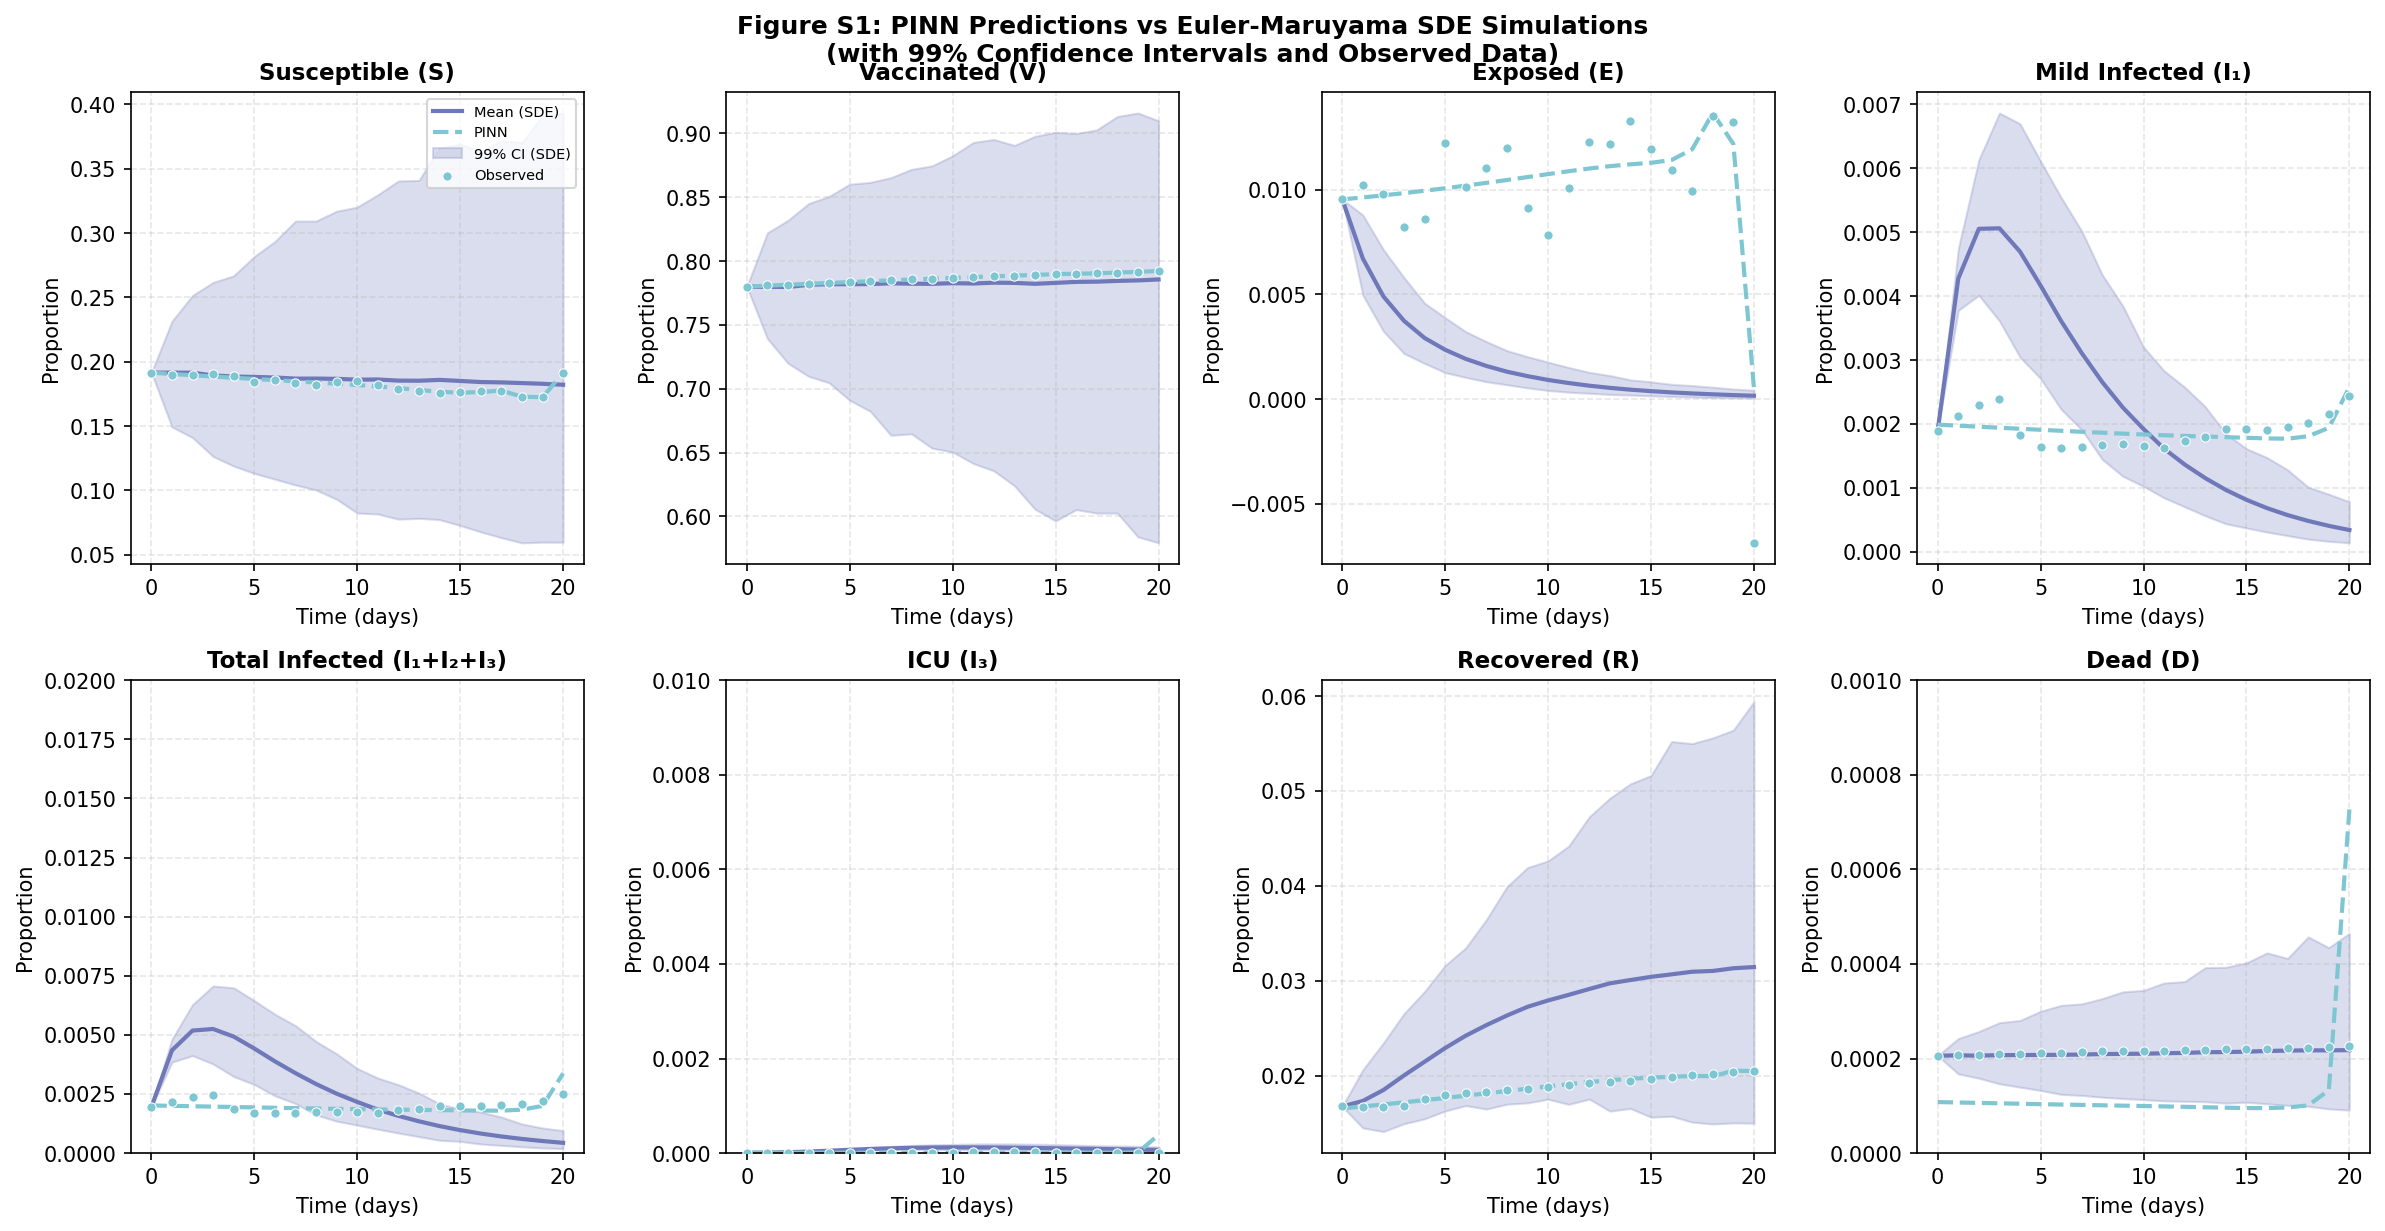

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o


Creating 6-panel figure...


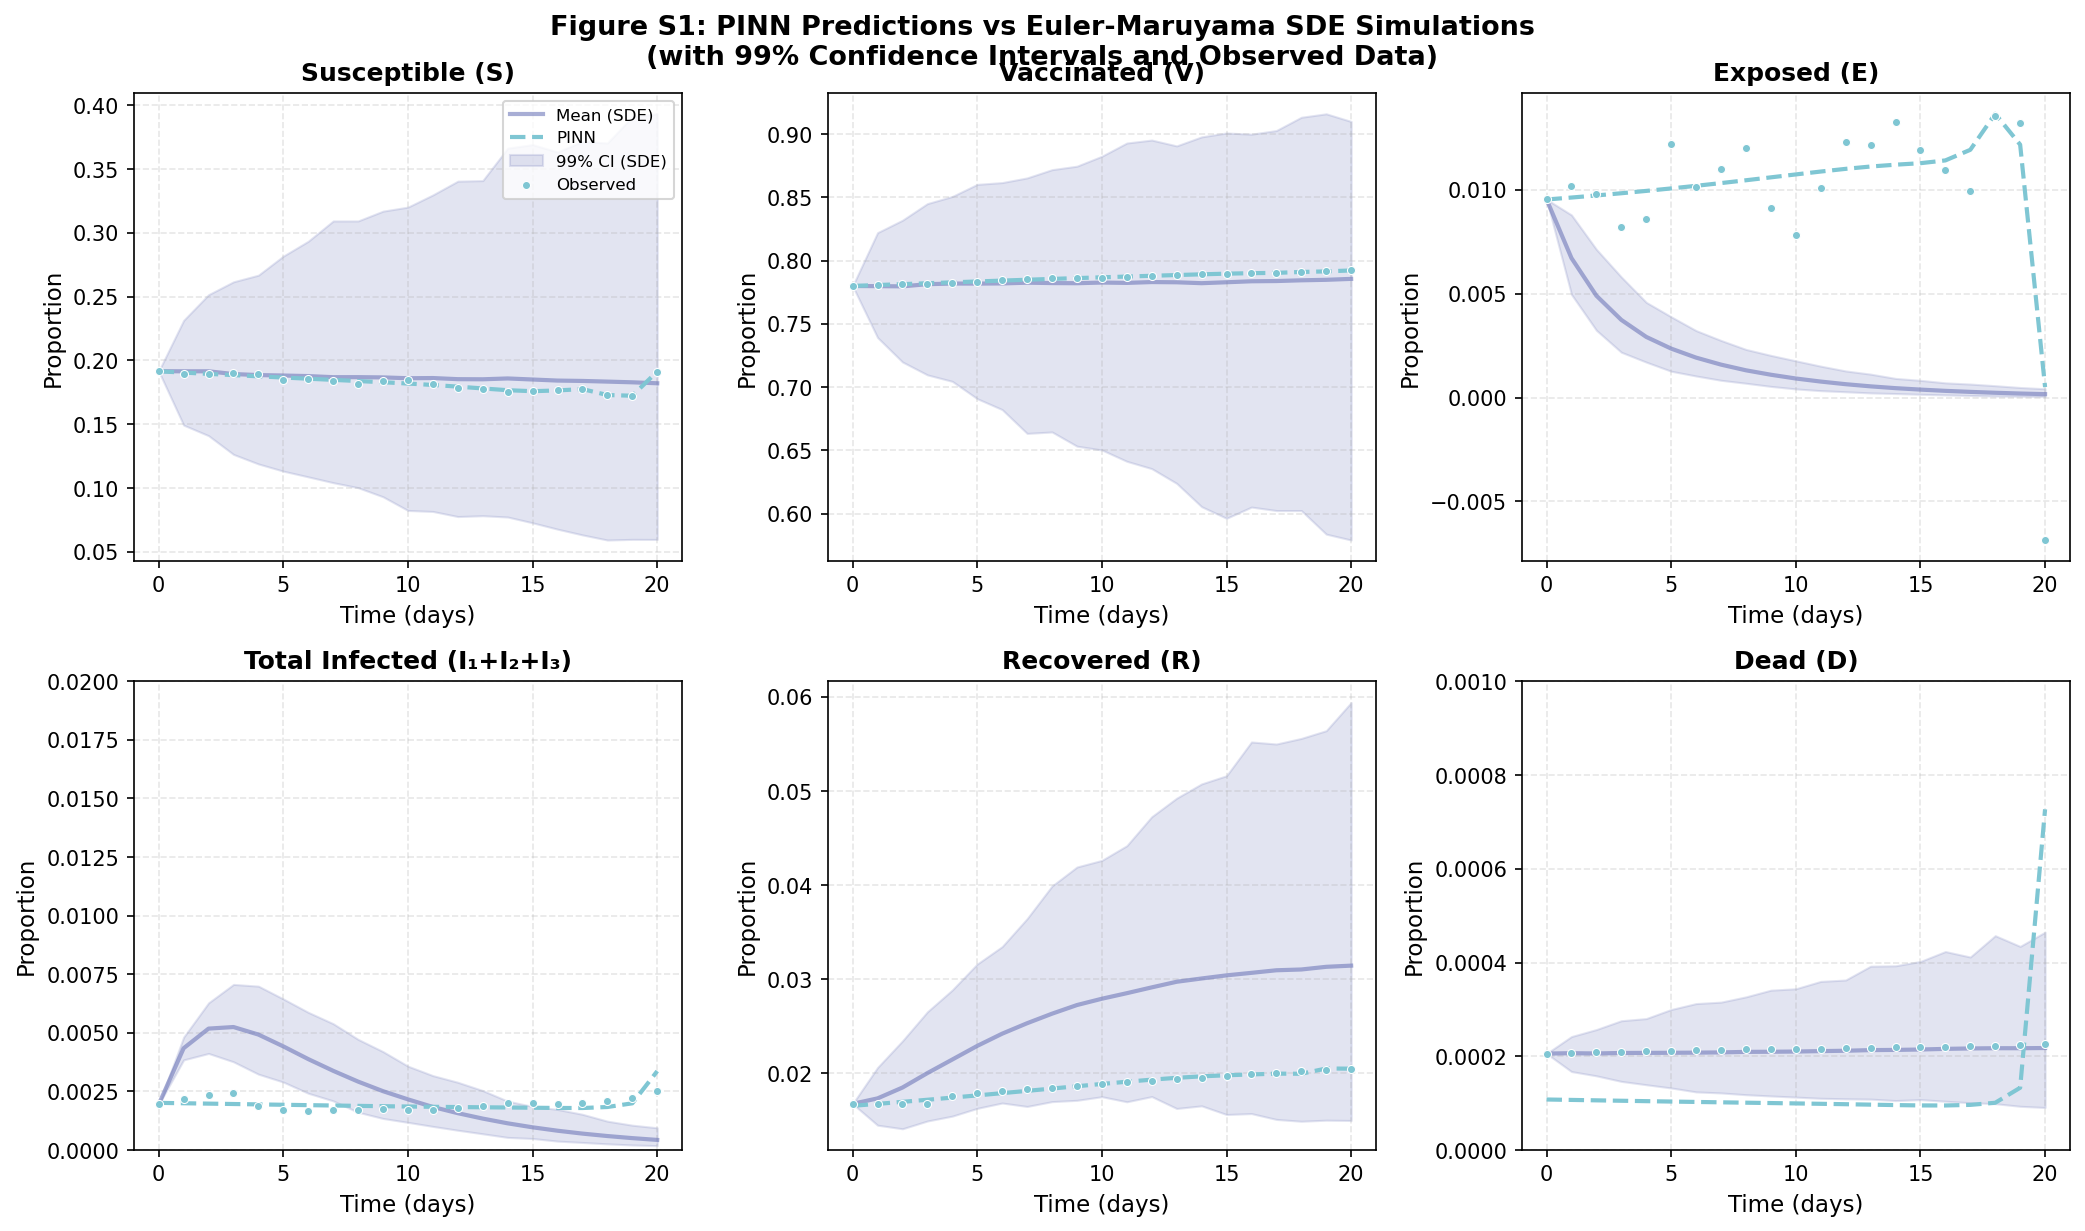


VALIDATION METRICS

1. RMSE (PINN vs SDE Mean):
--------------------------------------------------
   S       : 0.00597465
   V       : 0.00466158
   E       : 0.00907780
   I1      : 0.00164152
   I2      : 0.00013104
   I3      : 0.00010622
   I_total : 0.00176185
   R       : 0.00837119
   D       : 0.00015367

2. RMSE (PINN vs Observed):
--------------------------------------------------
   S       : 0.00123260
   V       : 0.00017441
   E       : 0.00207448
   I1      : 0.00020678
   I2      : 0.00008405
   I3      : 0.00008142
   I_total : 0.00028128
   R       : 0.00017567
   D       : 0.00015520

3. Coverage (Observed data within 99% CI):
--------------------------------------------------
   S       : 95.2% ✓
   V       : 95.2% ✓
   E       : 0.0% ⚠
   I1      : 28.6% ⚠
   I2      : 42.9% ⚠
   I3      : 0.0% ⚠
   I_total : 33.3% ⚠
   R       : 95.2% ✓
   D       : 95.2% ✓

4. Coverage (PINN within 99% CI):
--------------------------------------------------
   S       : 95.2% ✓

In [23]:
# =============================================================================
# PINN VALIDATION CODE - Combined Infected & Adjustable Y-Axis
# =============================================================================
# Features:
# 1. Combined I_total = I1 + I2 + I3 compartment
# 2. Adjustable y-axis limits for each compartment
# 3. Extended CI options
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

def euler_maruyama_svei3rd_extended(X0, t_span, params, n_mc=1000, seed=123, 
                                     substeps=10, normalize=True,
                                     volatility_scale=1.0, ci_percentile=95):
    """
    Euler-Maruyama simulation with extended CI options.
    Now also computes combined I_total = I1 + I2 + I3.
    """
    np.random.seed(seed)
    
    n_obs = len(t_span)
    dt_obs = t_span[1] - t_span[0] if n_obs > 1 else 1.0
    dt = dt_obs / substeps
    
    sigma_params = {
        'sigma1': params['sigma1'] * volatility_scale,
        'sigma2': params['sigma2'] * volatility_scale,
        'sigma3': params['sigma3'] * volatility_scale,
        'sigma4': params['sigma4'] * volatility_scale,
        'sigma5': params['sigma5'] * volatility_scale,
        'sigma6': params['sigma6'] * volatility_scale,
        'sigma7': params['sigma7'] * volatility_scale,
        'sigma8': params['sigma8'] * volatility_scale,
    }
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    trajectories = {comp: np.zeros((n_mc, n_obs)) for comp in compartments}
    
    print(f"Running {n_mc} MC simulations...")
    print(f"  Volatility scale: {volatility_scale}")
    print(f"  CI percentile: {ci_percentile}%")
    print(f"  Sub-steps: {substeps}")
    
    for mc in range(n_mc):
        if (mc + 1) % 200 == 0:
            print(f"  Progress: {mc+1}/{n_mc}")
        
        state = np.array(X0, dtype=np.float64)
        if normalize:
            state = state / np.sum(state)
        
        for i, comp in enumerate(compartments):
            trajectories[comp][mc, 0] = state[i]
        
        for obs_idx in range(1, n_obs):
            for _ in range(substeps):
                S, V, E, I1, I2, I3, R, D = state
                
                dW = np.random.normal(0, np.sqrt(dt), 8)
                foi = params['beta1'] * I1 + params['beta2'] * I2 + params['beta3'] * I3
                
                drift = np.array([
                    params['birth'] - foi * S - params['alpha'] * S - params['death'] * S,
                    params['alpha'] * S - params['sigma'] * foi * V - params['death'] * V,
                    foi * (S + params['sigma'] * V) - params['gamma'] * E - params['death'] * E,
                    params['gamma'] * E - (params['delta1'] + params['p1']) * I1 - params['death'] * I1,
                    params['p1'] * I1 - (params['delta2'] + params['p2']) * I2 - params['death'] * I2,
                    params['p2'] * I2 - (params['delta3'] + params['mu']) * I3 - params['death'] * I3,
                    params['delta1'] * I1 + params['delta2'] * I2 + params['delta3'] * I3 - params['death'] * R,
                    params['mu'] * I3
                ])
                
                diffusion = np.array([
                    sigma_params['sigma1'] * S * dW[0],
                    sigma_params['sigma2'] * V * dW[1],
                    sigma_params['sigma3'] * E * dW[2],
                    sigma_params['sigma4'] * I1 * dW[3],
                    sigma_params['sigma5'] * I2 * dW[4],
                    sigma_params['sigma6'] * I3 * dW[5],
                    sigma_params['sigma7'] * R * dW[6],
                    sigma_params['sigma8'] * D * dW[7]
                ])
                
                state = state + drift * dt + diffusion
                state = np.maximum(state, 0.0)
                
                if normalize:
                    total = np.sum(state)
                    if total > 0:
                        state = state / total
            
            for i, comp in enumerate(compartments):
                trajectories[comp][mc, obs_idx] = state[i]
    
    # Compute I_total = I1 + I2 + I3 for each MC run
    trajectories['I_total'] = trajectories['I1'] + trajectories['I2'] + trajectories['I3']
    
    # Compute percentiles
    lower_p = (100 - ci_percentile) / 2
    upper_p = 100 - lower_p
    
    all_comps = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D', 'I_total']
    mean_traj = {k: np.mean(trajectories[k], axis=0) for k in all_comps}
    ci_lower = {k: np.percentile(trajectories[k], lower_p, axis=0) for k in all_comps}
    ci_upper = {k: np.percentile(trajectories[k], upper_p, axis=0) for k in all_comps}
    std_traj = {k: np.std(trajectories[k], axis=0) for k in all_comps}
    
    print("Simulation complete!")
    return mean_traj, ci_lower, ci_upper, trajectories, std_traj


def create_validation_figure_with_itotal(observed, pinn_pred, mean_sde, ci_lower, ci_upper, 
                                          t_span, ci_label="95%", y_limits=None, save_path=None):
    """
    Create validation figure with combined I_total compartment.
    
    Parameters:
    -----------
    y_limits : dict, optional
        Dictionary specifying y-axis limits for each compartment.
        Example: {'S': (0, 0.6), 'V': (0.3, 0.9), 'I_total': (0, 0.02)}
        If None or compartment not specified, uses automatic limits.
    """
    new_purple = (111/255, 120/255, 185/255)
    new_red = (243/255, 114/255, 82/255)
    new_green = (127/255, 198/255, 211/255)

    if y_limits is None:
        y_limits = {}
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=150)
    
    # Updated compartment list with I_total instead of I2
    compartments = ['S', 'V', 'E', 'I1', 'I_total', 'I3', 'R', 'D']
    titles = ['Susceptible (S)', 'Vaccinated (V)', 'Exposed (E)', 'Mild Infected (I₁)',
              'Total Infected (I₁+I₂+I₃)', 'ICU (I₃)', 'Recovered (R)', 'Dead (D)']
    
    for idx, (ax, comp, title) in enumerate(zip(axes.flat, compartments, titles)):
        # CI band
        ax.fill_between(t_span, ci_lower[comp], ci_upper[comp], 
                        alpha=0.25, color=new_purple, label=f'{ci_label} CI (SDE)')
        
        # Mean SDE trajectory
        ax.plot(t_span, mean_sde[comp], '-', color=new_purple, 
                linewidth=2, label='Mean (SDE)')
        
        # PINN prediction
        ax.plot(t_span, pinn_pred[comp], '--', color=new_green, 
                linewidth=2, label='PINN')
        
        # Observed data points
        n_obs = len(observed[comp])
        step = max(1, n_obs // 25) if n_obs > 40 else 1
        obs_idx = np.arange(0, n_obs, step)
        
        ax.scatter(t_span[obs_idx], observed[comp][obs_idx], 
                   c=new_green, s=20, zorder=5, marker='o', 
                   label='Observed', edgecolors='white', linewidth=0.5)
        
        ax.set_xlabel('Time (days)', fontsize=10)
        ax.set_ylabel('Proportion', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set y-limits (custom or automatic)
        if comp in y_limits:
            ax.set_ylim(y_limits[comp])
        else:
            # Automatic limits
            all_vals = np.concatenate([observed[comp], pinn_pred[comp], 
                                       ci_lower[comp], ci_upper[comp]])
            ymin = max(0, np.min(all_vals) * 0.9)
            ymax = np.max(all_vals) * 1.1
            ax.set_ylim(ymin, ymax)
        
        if idx == 0:
            ax.legend(loc='upper right', fontsize=7)
    
    plt.suptitle(f'Figure S1: PINN Predictions vs Euler-Maruyama SDE Simulations\n'
                 f'(with {ci_label} Confidence Intervals and Observed Data)', 
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    
    plt.show()
    return fig


def create_validation_figure_6panel(observed, pinn_pred, mean_sde, ci_lower, ci_upper, 
                                     t_span, ci_label="95%", y_limits=None, save_path=None):
    """
    Create 6-panel validation figure: S, V, E, I_total, R, D
    (More compact, combines all infected into one panel)
    
    Parameters:
    -----------
    y_limits : dict, optional
        Example: {'S': (0, 0.6), 'I_total': (0, 0.02), 'D': (0, 0.0005)}
    """
    new_purple = (111/255, 120/255, 185/255)
    new_red = (243/255, 114/255, 82/255)
    
    if y_limits is None:
        y_limits = {}
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=150)
    
    compartments = ['S', 'V', 'E', 'I_total', 'R', 'D']
    titles = ['Susceptible (S)', 'Vaccinated (V)', 'Exposed (E)', 
              'Total Infected (I₁+I₂+I₃)', 'Recovered (R)', 'Dead (D)']
    
    for idx, (ax, comp, title) in enumerate(zip(axes.flat, compartments, titles)):
        # CI band
        ax.fill_between(t_span, ci_lower[comp], ci_upper[comp], 
                        alpha=0.2, color=new_purple, label=f'{ci_label} CI (SDE)')
        
        # Mean SDE trajectory
        ax.plot(t_span, mean_sde[comp], '-', color=new_purple, alpha=0.6,
                linewidth=2, label='Mean (SDE)')
        
        # PINN prediction
        ax.plot(t_span, pinn_pred[comp], '--', color=new_green, 
                linewidth=2, label='PINN')
        
        # Observed data points
        n_obs = len(observed[comp])
        step = max(1, n_obs // 25) if n_obs > 40 else 1
        obs_idx = np.arange(0, n_obs, step)
        
        ax.scatter(t_span[obs_idx], observed[comp][obs_idx], 
                   c=new_green, s=15, zorder=5, marker='o', 
                   label='Observed', edgecolors='white', linewidth=0.5)
        
        ax.set_xlabel('Time (days)', fontsize=11)
        ax.set_ylabel('Proportion', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set y-limits
        if comp in y_limits:
            ax.set_ylim(y_limits[comp])
        else:
            all_vals = np.concatenate([observed[comp], pinn_pred[comp], 
                                       ci_lower[comp], ci_upper[comp]])
            ymin = max(0, np.min(all_vals) * 0.9)
            ymax = np.max(all_vals) * 1.1
            ax.set_ylim(ymin, ymax)
        
        if idx == 0:
            ax.legend(loc='upper right', fontsize=8)
    
    plt.suptitle(f'Figure S1: PINN Predictions vs Euler-Maruyama SDE Simulations\n'
                 f'(with {ci_label} Confidence Intervals and Observed Data)', 
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    
    plt.show()
    return fig


def compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label="95%"):
    """Compute validation metrics including I_total."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'I_total', 'R', 'D']
    
    print("\n" + "="*70)
    print("VALIDATION METRICS")
    print("="*70)
    
    print("\n1. RMSE (PINN vs SDE Mean):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        print(f"   {comp:8s}: {rmse:.8f}")
    
    print("\n2. RMSE (PINN vs Observed):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        print(f"   {comp:8s}: {rmse:.8f}")
    
    print(f"\n3. Coverage (Observed data within {ci_label} CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((observed[comp] >= ci_lower[comp]) & 
                        (observed[comp] <= ci_upper[comp])) * 100
        status = "✓" if within >= 90 else "⚠"
        print(f"   {comp:8s}: {within:.1f}% {status}")
    
    print(f"\n4. Coverage (PINN within {ci_label} CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((pinn_pred[comp] >= ci_lower[comp]) & 
                        (pinn_pred[comp] <= ci_upper[comp])) * 100
        status = "✓" if within >= 90 else "⚠"
        print(f"   {comp:8s}: {within:.1f}% {status}")


def generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label="95"):
    """Generate LaTeX table including I_total."""
    compartments = ['S', 'V', 'E', 'I_total', 'R', 'D']
    comp_names = {
        'S': 'Susceptible ($S$)', 
        'V': 'Vaccinated ($V$)', 
        'E': 'Exposed ($E$)', 
        'I_total': 'Total Infected ($I_1+I_2+I_3$)',
        'R': 'Recovered ($R$)', 
        'D': 'Dead ($D$)'
    }
    
    print("\n" + "="*70)
    print("LATEX TABLE")
    print("="*70)
    
    latex = rf"""
\begin{{table}}[htbp]
\centering
\caption{{Goodness-of-fit metrics comparing PINN predictions with Euler-Maruyama 
SDE simulations. Coverage indicates the percentage of observed data points 
falling within the {ci_label}\% confidence interval from 1,000 Monte Carlo simulations.}}
\label{{tab:pinn_validation}}
\begin{{tabular}}{{lcccc}}
\toprule
Compartment & RMSE (PINN vs SDE) & RMSE (PINN vs Obs) & Coverage (\%) & $N$ \\
\midrule
"""
    
    for comp in compartments:
        rmse_sde = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        rmse_obs = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        coverage = np.mean((observed[comp] >= ci_lower[comp]) & 
                          (observed[comp] <= ci_upper[comp])) * 100
        n_points = len(observed[comp])
        
        latex += f"{comp_names[comp]} & {rmse_sde:.6f} & {rmse_obs:.6f} & {coverage:.1f} & {n_points} \\\\\n"
    
    latex += r"""\bottomrule
\end{tabular}
\end{table}
"""
    print(latex)
    return latex


# =============================================================================
# RUN VALIDATION
# =============================================================================

# Step 1: Prepare observed data (including I_total)
observed = {
    'S': SS.flatten(), 
    'V': VV.flatten(), 
    'E': EE.flatten(),
    'I1': I1I.flatten(), 
    'I2': I2I.flatten(), 
    'I3': I3I.flatten(),
    'R': RR.flatten(), 
    'D': DD.flatten()
}
# Add combined infected
observed['I_total'] = observed['I1'] + observed['I2'] + observed['I3']

# Step 2: Prepare PINN predictions (including I_total)
pinn_pred = {
    'S': S_pred_m.flatten(), 
    'V': V_pred_m.flatten(), 
    'E': E_pred_m.flatten(),
    'I1': I1_pred_m.flatten(), 
    'I2': I2_pred_m.flatten(), 
    'I3': I3_pred_m.flatten(),
    'R': R_pred_m.flatten(), 
    'D': D_pred_m.flatten()
}
# Add combined infected
pinn_pred['I_total'] = pinn_pred['I1'] + pinn_pred['I2'] + pinn_pred['I3']

# Step 3: Initial conditions
X0_raw = [
    SS.flatten()[0], VV.flatten()[0], EE.flatten()[0], 
    I1I.flatten()[0], I2I.flatten()[0], I3I.flatten()[0], 
    RR.flatten()[0], DD.flatten()[0]
]
X0 = np.array(X0_raw) / np.sum(X0_raw)

# Step 4: Parameters dictionary
params = {
    'alpha': alpha, 'sigma': sigma,
    'beta1': beta1, 'beta2': beta2, 'beta3': beta3,
    'delta1': delta1, 'delta2': delta2, 'delta3': delta3,
    'gamma': gamma, 'p1': p1, 'p2': p2, 'mu': mu,
    'birth': birth_rt, 'death': death_rt,
    'sigma1': sigma1, 'sigma2': sigma2, 'sigma3': sigma3,
    'sigma4': sigma4, 'sigma5': sigma5, 'sigma6': sigma6,
    'sigma7': sigma7, 'sigma8': sigma8
}

# Step 5: Time span
n_points = len(SS.flatten())
t_span = np.linspace(0, 20, n_points)  # Adjust 60 to your ub value

# =============================================================================
# SETTINGS - ADJUST THESE
# =============================================================================
VOLATILITY_SCALE = 1.0   # Scale factor for σ parameters
CI_PERCENTILE = 99       # Confidence interval width
SUBSTEPS = 1            # Sub-steps for numerical stability

# =============================================================================
# Y-AXIS LIMITS - CUSTOMIZE FOR EACH COMPARTMENT
# =============================================================================
# Set to None for automatic limits, or specify (ymin, ymax) tuple
# Example: 'S': (0.1, 0.6) means y-axis from 0.1 to 0.6

Y_LIMITS = {
    'S': None,           # Auto: try (0.1, 0.6) if needed
    'V': None,           # Auto: try (0.3, 0.9) if needed
    'E': None,           # Auto: try (0, 0.015) if needed
    'I1': None,          # Auto
    'I2': None,          # Auto
    'I3':  (0, 0.01),          # Auto
    'I_total': (0, 0.02),     # Auto: try (0, 0.015) if needed
    'R': None,           # Auto: try (0, 0.05) if needed
    'D': (0, 0.001) ,           # Auto: try (0, 0.0003) if needed
}

# =============================================================================
# RUN SIMULATION
# =============================================================================
print("="*70)
print("RUNNING EULER-MARUYAMA WITH EXTENDED CI")
print("="*70)

mean_sde, ci_lower, ci_upper, trajectories, std_sde = euler_maruyama_svei3rd_extended(
    X0, t_span, params, 
    n_mc=1000,
    seed=12345,
    substeps=SUBSTEPS,
    normalize=True,
    volatility_scale=VOLATILITY_SCALE,
    ci_percentile=CI_PERCENTILE
)

ci_label = f"{CI_PERCENTILE}%"

# =============================================================================
# CREATE FIGURES
# =============================================================================

# Option 1: 8-panel figure (with I_total replacing I2)
print("\nCreating 8-panel figure...")
fig1 = create_validation_figure_with_itotal(
    observed, pinn_pred, mean_sde, ci_lower, ci_upper, t_span,
    ci_label=ci_label,
    y_limits=Y_LIMITS,
    save_path='FigS1_PINN_validation_8panel.png'
)

# Option 2: 6-panel figure (S, V, E, I_total, R, D)
print("\nCreating 6-panel figure...")
fig2 = create_validation_figure_6panel(
    observed, pinn_pred, mean_sde, ci_lower, ci_upper, t_span,
    ci_label=ci_label,
    y_limits=Y_LIMITS,
    save_path='FigS1_PINN_validation_6panel.png'
)

# =============================================================================
# COMPUTE METRICS
# =============================================================================
compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label)

# =============================================================================
# GENERATE LATEX TABLE
# =============================================================================
generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper, str(CI_PERCENTILE))

print("\n" + "="*70)
print("VALIDATION COMPLETE!")
print("="*70)

## new

In [29]:
def set_figure_style():
    """Set consistent style for all figures in the paper."""
    
    plt.rcParams.update({
        # Font settings
        'font.family': 'serif',
        'font.serif': ['Times New Roman'],
        'font.size': 10,
        
        # Title and label sizes
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'figure.titlesize': 12,
        
        # Line and marker settings
        'lines.linewidth': 1.5,
        'lines.markersize': 5,
        
        # Legend settings
        'legend.frameon': True,
        'legend.framealpha': 0.8,
        
        # Figure settings
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        
        # Axis settings
        'axes.linewidth': 0.8,
        'axes.grid': False,
        
        # Tick settings
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.size': 4,
        'ytick.major.size': 4,
    })


RUNNING EULER-MARUYAMA WITH EXTENDED CI
Running 10000 MC simulations...
  Volatility scale: 1.0
  CI percentile: 99%
  Sub-steps: 1
  Progress: 200/10000
  Progress: 400/10000
  Progress: 600/10000
  Progress: 800/10000
  Progress: 1000/10000
  Progress: 1200/10000
  Progress: 1400/10000
  Progress: 1600/10000
  Progress: 1800/10000
  Progress: 2000/10000
  Progress: 2200/10000
  Progress: 2400/10000
  Progress: 2600/10000
  Progress: 2800/10000
  Progress: 3000/10000
  Progress: 3200/10000
  Progress: 3400/10000
  Progress: 3600/10000
  Progress: 3800/10000
  Progress: 4000/10000
  Progress: 4200/10000
  Progress: 4400/10000
  Progress: 4600/10000
  Progress: 4800/10000
  Progress: 5000/10000
  Progress: 5200/10000
  Progress: 5400/10000
  Progress: 5600/10000
  Progress: 5800/10000
  Progress: 6000/10000
  Progress: 6200/10000
  Progress: 6400/10000
  Progress: 6600/10000
  Progress: 6800/10000
  Progress: 7000/10000
  Progress: 7200/10000
  Progress: 7400/10000
  Progress: 7600/1000

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

  Progress: 9800/10000
  Progress: 10000/10000
Simulation complete!


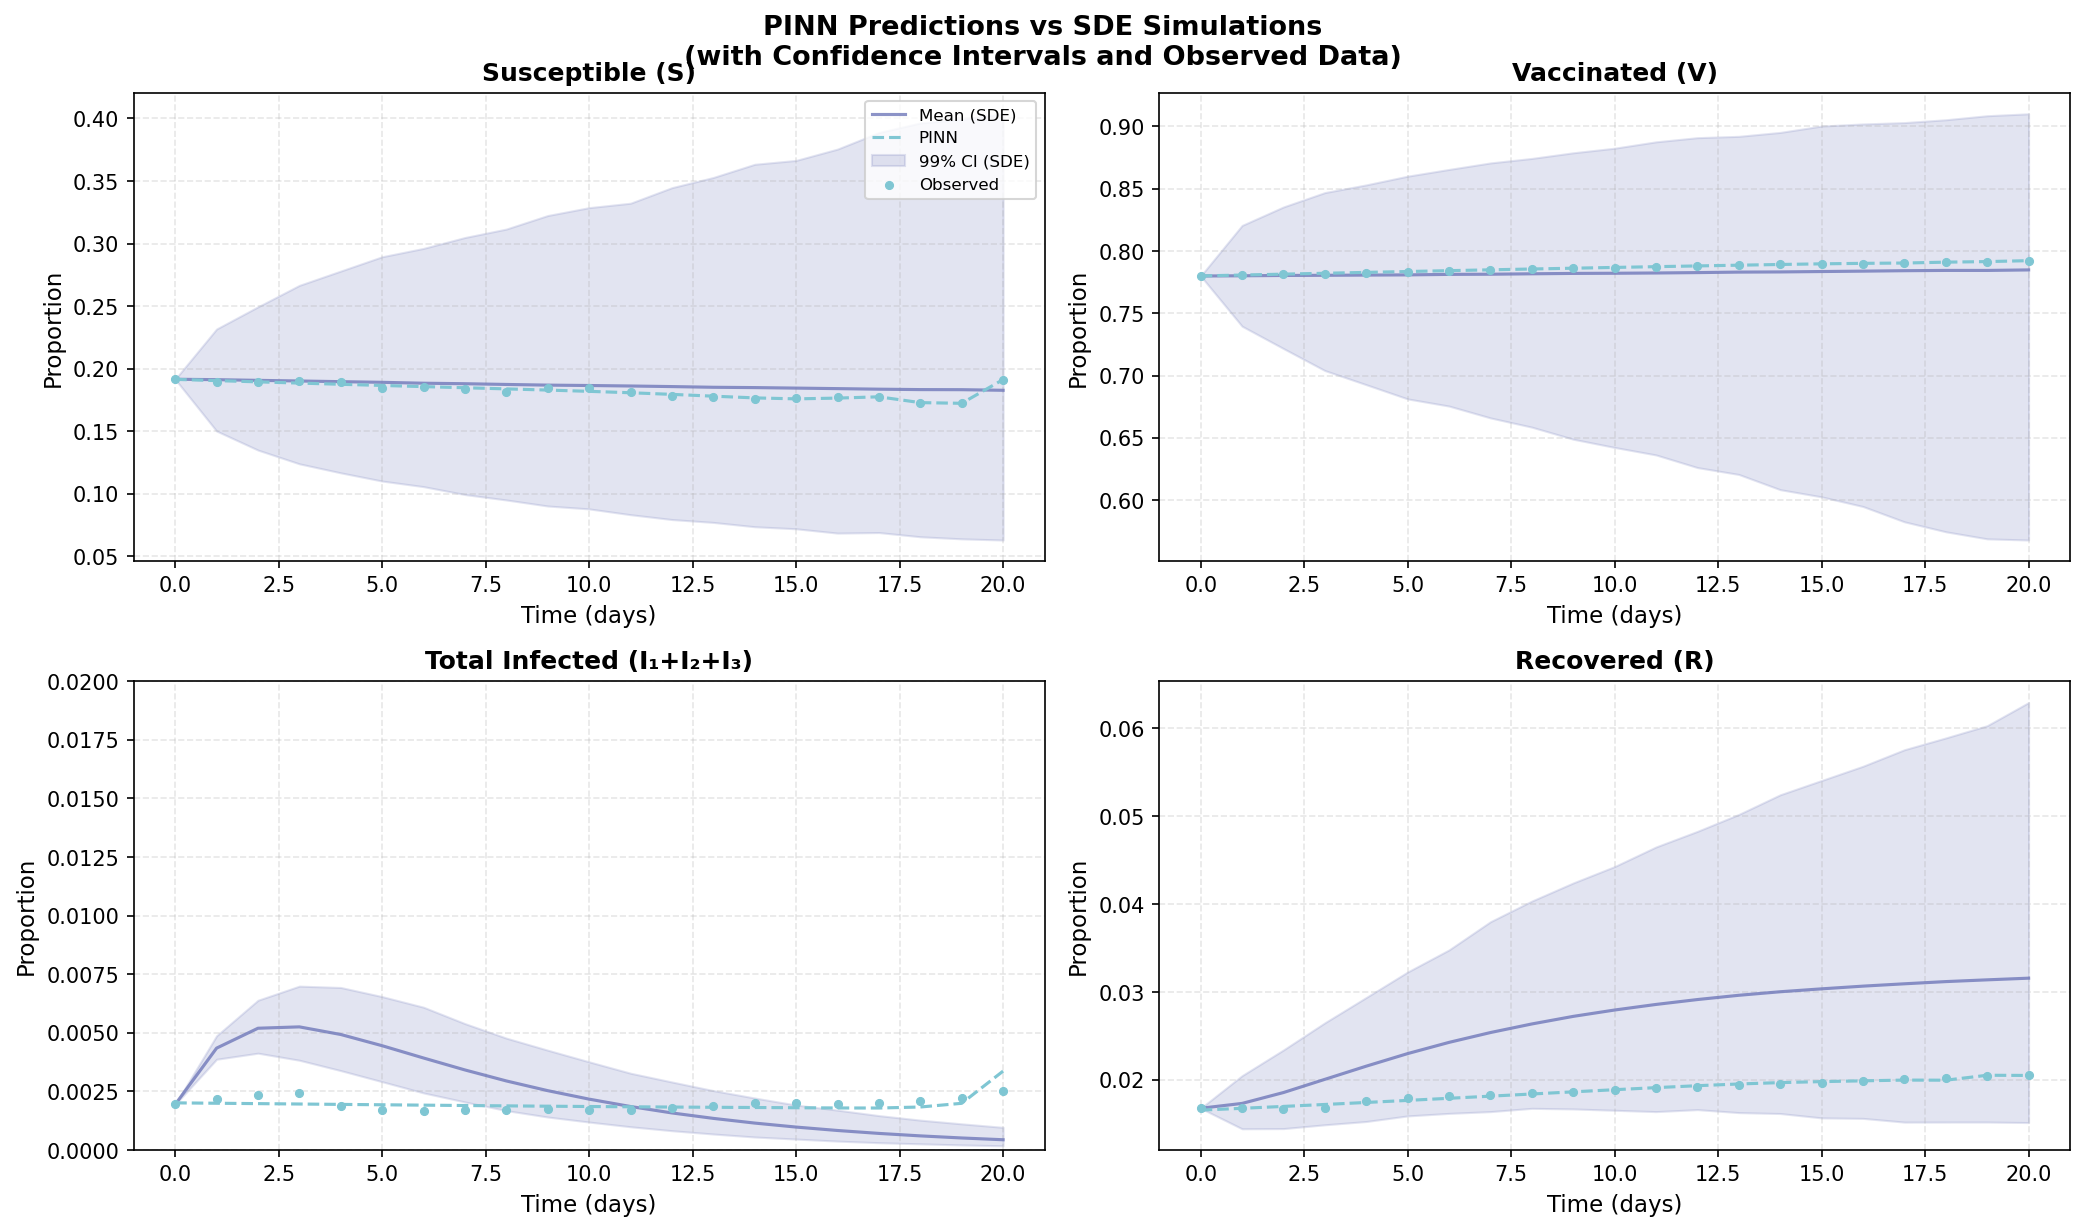


VALIDATION METRICS

1. RMSE (PINN vs SDE Mean):
--------------------------------------------------
   S       : 0.00592898
   V       : 0.00476820
   E       : 0.00907387
   I1      : 0.00164777
   I2      : 0.00013169
   I3      : 0.00010681
   I_total : 0.00176931
   R       : 0.00838571
   D       : 0.00015349

2. RMSE (PINN vs Observed):
--------------------------------------------------
   S       : 0.00123260
   V       : 0.00017441
   E       : 0.00207448
   I1      : 0.00020678
   I2      : 0.00008405
   I3      : 0.00008142
   I_total : 0.00028128
   R       : 0.00017567
   D       : 0.00015520

3. Coverage (Observed data within 99% CI):
--------------------------------------------------
   S       : 95.2% ✓
   V       : 95.2% ✓
   E       : 0.0% ⚠
   I1      : 33.3% ⚠
   I2      : 42.9% ⚠
   I3      : 0.0% ⚠
   I_total : 33.3% ⚠
   R       : 95.2% ✓
   D       : 95.2% ✓

4. Coverage (PINN within 99% CI):
--------------------------------------------------
   S       : 95.2% ✓

In [30]:
# =============================================================================
# PINN VALIDATION CODE - Combined Infected & Adjustable Y-Axis
# =============================================================================
# Features:
# 1. Combined I_total = I1 + I2 + I3 compartment
# 2. Adjustable y-axis limits for each compartment
# 3. Extended CI options
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

def euler_maruyama_svei3rd_extended(X0, t_span, params, n_mc=1000, seed=123, 
                                     substeps=10, normalize=True,
                                     volatility_scale=1.0, ci_percentile=95):
    """
    Euler-Maruyama simulation with extended CI options.
    Now also computes combined I_total = I1 + I2 + I3.
    """
    np.random.seed(seed)
    
    n_obs = len(t_span)
    dt_obs = t_span[1] - t_span[0] if n_obs > 1 else 1.0
    dt = dt_obs / substeps
    
    sigma_params = {
        'sigma1': params['sigma1'] * volatility_scale,
        'sigma2': params['sigma2'] * volatility_scale,
        'sigma3': params['sigma3'] * volatility_scale,
        'sigma4': params['sigma4'] * volatility_scale,
        'sigma5': params['sigma5'] * volatility_scale,
        'sigma6': params['sigma6'] * volatility_scale,
        'sigma7': params['sigma7'] * volatility_scale,
        'sigma8': params['sigma8'] * volatility_scale,
    }
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    trajectories = {comp: np.zeros((n_mc, n_obs)) for comp in compartments}
    
    print(f"Running {n_mc} MC simulations...")
    print(f"  Volatility scale: {volatility_scale}")
    print(f"  CI percentile: {ci_percentile}%")
    print(f"  Sub-steps: {substeps}")
    
    for mc in range(n_mc):
        if (mc + 1) % 200 == 0:
            print(f"  Progress: {mc+1}/{n_mc}")
        
        state = np.array(X0, dtype=np.float64)
        if normalize:
            state = state / np.sum(state)
        
        for i, comp in enumerate(compartments):
            trajectories[comp][mc, 0] = state[i]
        
        for obs_idx in range(1, n_obs):
            for _ in range(substeps):
                S, V, E, I1, I2, I3, R, D = state
                
                dW = np.random.normal(0, np.sqrt(dt), 8)
                foi = params['beta1'] * I1 + params['beta2'] * I2 + params['beta3'] * I3
                
                drift = np.array([
                    params['birth'] - foi * S - params['alpha'] * S - params['death'] * S,
                    params['alpha'] * S - params['sigma'] * foi * V - params['death'] * V,
                    foi * (S + params['sigma'] * V) - params['gamma'] * E - params['death'] * E,
                    params['gamma'] * E - (params['delta1'] + params['p1']) * I1 - params['death'] * I1,
                    params['p1'] * I1 - (params['delta2'] + params['p2']) * I2 - params['death'] * I2,
                    params['p2'] * I2 - (params['delta3'] + params['mu']) * I3 - params['death'] * I3,
                    params['delta1'] * I1 + params['delta2'] * I2 + params['delta3'] * I3 - params['death'] * R,
                    params['mu'] * I3
                ])
                
                diffusion = np.array([
                    sigma_params['sigma1'] * S * dW[0],
                    sigma_params['sigma2'] * V * dW[1],
                    sigma_params['sigma3'] * E * dW[2],
                    sigma_params['sigma4'] * I1 * dW[3],
                    sigma_params['sigma5'] * I2 * dW[4],
                    sigma_params['sigma6'] * I3 * dW[5],
                    sigma_params['sigma7'] * R * dW[6],
                    sigma_params['sigma8'] * D * dW[7]
                ])
                
                state = state + drift * dt + diffusion
                state = np.maximum(state, 0.0)
                
                if normalize:
                    total = np.sum(state)
                    if total > 0:
                        state = state / total
            
            for i, comp in enumerate(compartments):
                trajectories[comp][mc, obs_idx] = state[i]
    
    # Compute I_total = I1 + I2 + I3 for each MC run
    trajectories['I_total'] = trajectories['I1'] + trajectories['I2'] + trajectories['I3']
    
    # Compute percentiles
    lower_p = (100 - ci_percentile) / 2
    upper_p = 100 - lower_p
    
    all_comps = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D', 'I_total']
    mean_traj = {k: np.mean(trajectories[k], axis=0) for k in all_comps}
    ci_lower = {k: np.percentile(trajectories[k], lower_p, axis=0) for k in all_comps}
    ci_upper = {k: np.percentile(trajectories[k], upper_p, axis=0) for k in all_comps}
    std_traj = {k: np.std(trajectories[k], axis=0) for k in all_comps}
    
    print("Simulation complete!")
    return mean_traj, ci_lower, ci_upper, trajectories, std_traj


def create_validation_figure_4panel(observed, pinn_pred, mean_sde, ci_lower, ci_upper, 
                                     t_span, ci_label="95%", y_limits=None, save_path=None):
    """
    Create 6-panel validation figure: S, V, E, I_total, R, D
    (More compact, combines all infected into one panel)
    
    Parameters:
    -----------
    y_limits : dict, optional
        Example: {'S': (0, 0.6), 'I_total': (0, 0.02), 'D': (0, 0.0005)}
    """
    new_purple = (111/255, 120/255, 185/255)
    m_orange = (253/255, 207/255, 158/255)
   
    m_blue = (209/255, 226/255, 239/255)
    m_green3 = (127/255, 198/255, 211/255)

    
    if y_limits is None:
        y_limits = {}
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=150)
    
    compartments = ['S', 'V', 'I_total', 'R']
    titles = ['Susceptible (S)', 'Vaccinated (V)', 
              'Total Infected (I₁+I₂+I₃)', 'Recovered (R)']
    
    for idx, (ax, comp, title) in enumerate(zip(axes.flat, compartments, titles)):
        # CI band
        ax.fill_between(t_span, ci_lower[comp], ci_upper[comp], 
                        alpha=0.2, color=new_purple, label=f'{ci_label} CI (SDE)')
        
        # Mean SDE trajectory
        ax.plot(t_span, mean_sde[comp], '-', color=new_purple, alpha=0.8,
                linewidth=1.5, label='Mean (SDE)')
        
        # PINN prediction
        ax.plot(t_span, pinn_pred[comp], '--', color=m_green3, 
                linewidth=1.5, label='PINN')
        
        # Observed data points
        n_obs = len(observed[comp])
        step = max(1, n_obs // 25) if n_obs > 40 else 1
        obs_idx = np.arange(0, n_obs, step)
        
        ax.scatter(t_span[obs_idx], observed[comp][obs_idx], 
                   c=m_green3, s=15, zorder=5, marker='o', 
                   label='Observed', linewidth=0.5)
        
        ax.set_xlabel('Time (days)', fontsize=11)
        ax.set_ylabel('Proportion', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set y-limits
        if comp in y_limits:
            ax.set_ylim(y_limits[comp])
        else:
            all_vals = np.concatenate([observed[comp], pinn_pred[comp], 
                                       ci_lower[comp], ci_upper[comp]])
            ymin = max(0, np.min(all_vals) * 0.9)
            ymax = np.max(all_vals) * 1.1
            ax.set_ylim(ymin, ymax)
        
        if idx == 0:
            ax.legend(loc='upper right', fontsize=8)
    
    plt.suptitle(f'PINN Predictions vs SDE Simulations\n'
                 f'(with Confidence Intervals and Observed Data)', 
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    
    plt.show()
    return fig


def compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label="95%"):
    """Compute validation metrics including I_total."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'I_total', 'R', 'D']
    
    print("\n" + "="*70)
    print("VALIDATION METRICS")
    print("="*70)
    
    print("\n1. RMSE (PINN vs SDE Mean):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        print(f"   {comp:8s}: {rmse:.8f}")
    
    print("\n2. RMSE (PINN vs Observed):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        print(f"   {comp:8s}: {rmse:.8f}")
    
    print(f"\n3. Coverage (Observed data within {ci_label} CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((observed[comp] >= ci_lower[comp]) & 
                        (observed[comp] <= ci_upper[comp])) * 100
        status = "✓" if within >= 90 else "⚠"
        print(f"   {comp:8s}: {within:.1f}% {status}")
    
    print(f"\n4. Coverage (PINN within {ci_label} CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((pinn_pred[comp] >= ci_lower[comp]) & 
                        (pinn_pred[comp] <= ci_upper[comp])) * 100
        status = "✓" if within >= 90 else "⚠"
        print(f"   {comp:8s}: {within:.1f}% {status}")



# =============================================================================
# RUN VALIDATION
# =============================================================================

# Step 1: Prepare observed data (including I_total)
observed = {
    'S': SS.flatten(), 
    'V': VV.flatten(), 
    'E': EE.flatten(),
    'I1': I1I.flatten(), 
    'I2': I2I.flatten(), 
    'I3': I3I.flatten(),
    'R': RR.flatten(), 
    'D': DD.flatten()
}
# Add combined infected
observed['I_total'] = observed['I1'] + observed['I2'] + observed['I3']

# Step 2: Prepare PINN predictions (including I_total)
pinn_pred = {
    'S': S_pred_m.flatten(), 
    'V': V_pred_m.flatten(), 
    'E': E_pred_m.flatten(),
    'I1': I1_pred_m.flatten(), 
    'I2': I2_pred_m.flatten(), 
    'I3': I3_pred_m.flatten(),
    'R': R_pred_m.flatten(), 
    'D': D_pred_m.flatten()
}
# Add combined infected
pinn_pred['I_total'] = pinn_pred['I1'] + pinn_pred['I2'] + pinn_pred['I3']

# Step 3: Initial conditions
X0_raw = [
    SS.flatten()[0], VV.flatten()[0], EE.flatten()[0], 
    I1I.flatten()[0], I2I.flatten()[0], I3I.flatten()[0], 
    RR.flatten()[0], DD.flatten()[0]
]
X0 = np.array(X0_raw) / np.sum(X0_raw)

# Step 4: Parameters dictionary
params = {
    'alpha': alpha, 'sigma': sigma,
    'beta1': beta1, 'beta2': beta2, 'beta3': beta3,
    'delta1': delta1, 'delta2': delta2, 'delta3': delta3,
    'gamma': gamma, 'p1': p1, 'p2': p2, 'mu': mu,
    'birth': birth_rt, 'death': death_rt,
    'sigma1': sigma1, 'sigma2': sigma2, 'sigma3': sigma3,
    'sigma4': sigma4, 'sigma5': sigma5, 'sigma6': sigma6,
    'sigma7': sigma7, 'sigma8': sigma8
}

# Step 5: Time span
n_points = len(SS.flatten())
t_span = np.linspace(0, 20, n_points)  # Adjust 60 to your ub value

# =============================================================================
# SETTINGS - ADJUST THESE
# =============================================================================
VOLATILITY_SCALE = 1.0   # Scale factor for σ parameters
CI_PERCENTILE = 99       # Confidence interval width
SUBSTEPS = 1            # Sub-steps for numerical stability

# =============================================================================
# Y-AXIS LIMITS - CUSTOMIZE FOR EACH COMPARTMENT
# =============================================================================
# Set to None for automatic limits, or specify (ymin, ymax) tuple
# Example: 'S': (0.1, 0.6) means y-axis from 0.1 to 0.6

Y_LIMITS = {
    'S': None,           # Auto: try (0.1, 0.6) if needed
    'V': None,           # Auto: try (0.3, 0.9) if needed
    'E': None,           # Auto: try (0, 0.015) if needed
    'I1': None,          # Auto
    'I2': None,          # Auto
    'I3':  (0, 0.01),          # Auto
    'I_total': (0, 0.02),     # Auto: try (0, 0.015) if needed
    'R': None,           # Auto: try (0, 0.05) if needed
    'D': (0, 0.001) ,           # Auto: try (0, 0.0003) if needed
}

# =============================================================================
# RUN SIMULATION
# =============================================================================
print("="*70)
print("RUNNING EULER-MARUYAMA WITH EXTENDED CI")
print("="*70)

mean_sde, ci_lower, ci_upper, trajectories, std_sde = euler_maruyama_svei3rd_extended(
    X0, t_span, params, 
    n_mc=10000,
    seed=12345,
    substeps=SUBSTEPS,
    normalize=True,
    volatility_scale=VOLATILITY_SCALE,
    ci_percentile=CI_PERCENTILE
)

ci_label = f"{CI_PERCENTILE}%"

# =============================================================================
# CREATE FIGURES
# =============================================================================

# Option 1: 8-panel figure (with I_total replacing I2)


# Option 2: 6-panel figure (S, V, E, I_total, R, D)

fig2 = create_validation_figure_4panel(
    observed, pinn_pred, mean_sde, ci_lower, ci_upper, t_span,
    ci_label=ci_label,
    y_limits=Y_LIMITS
)

# =============================================================================
# COMPUTE METRICS
# =============================================================================
compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label)

# =============================================================================
# GENERATE LATEX TABLE
# =============================================================================
generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper, str(CI_PERCENTILE))

print("\n" + "="*70)
print("VALIDATION COMPLETE!")
print("="*70)

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

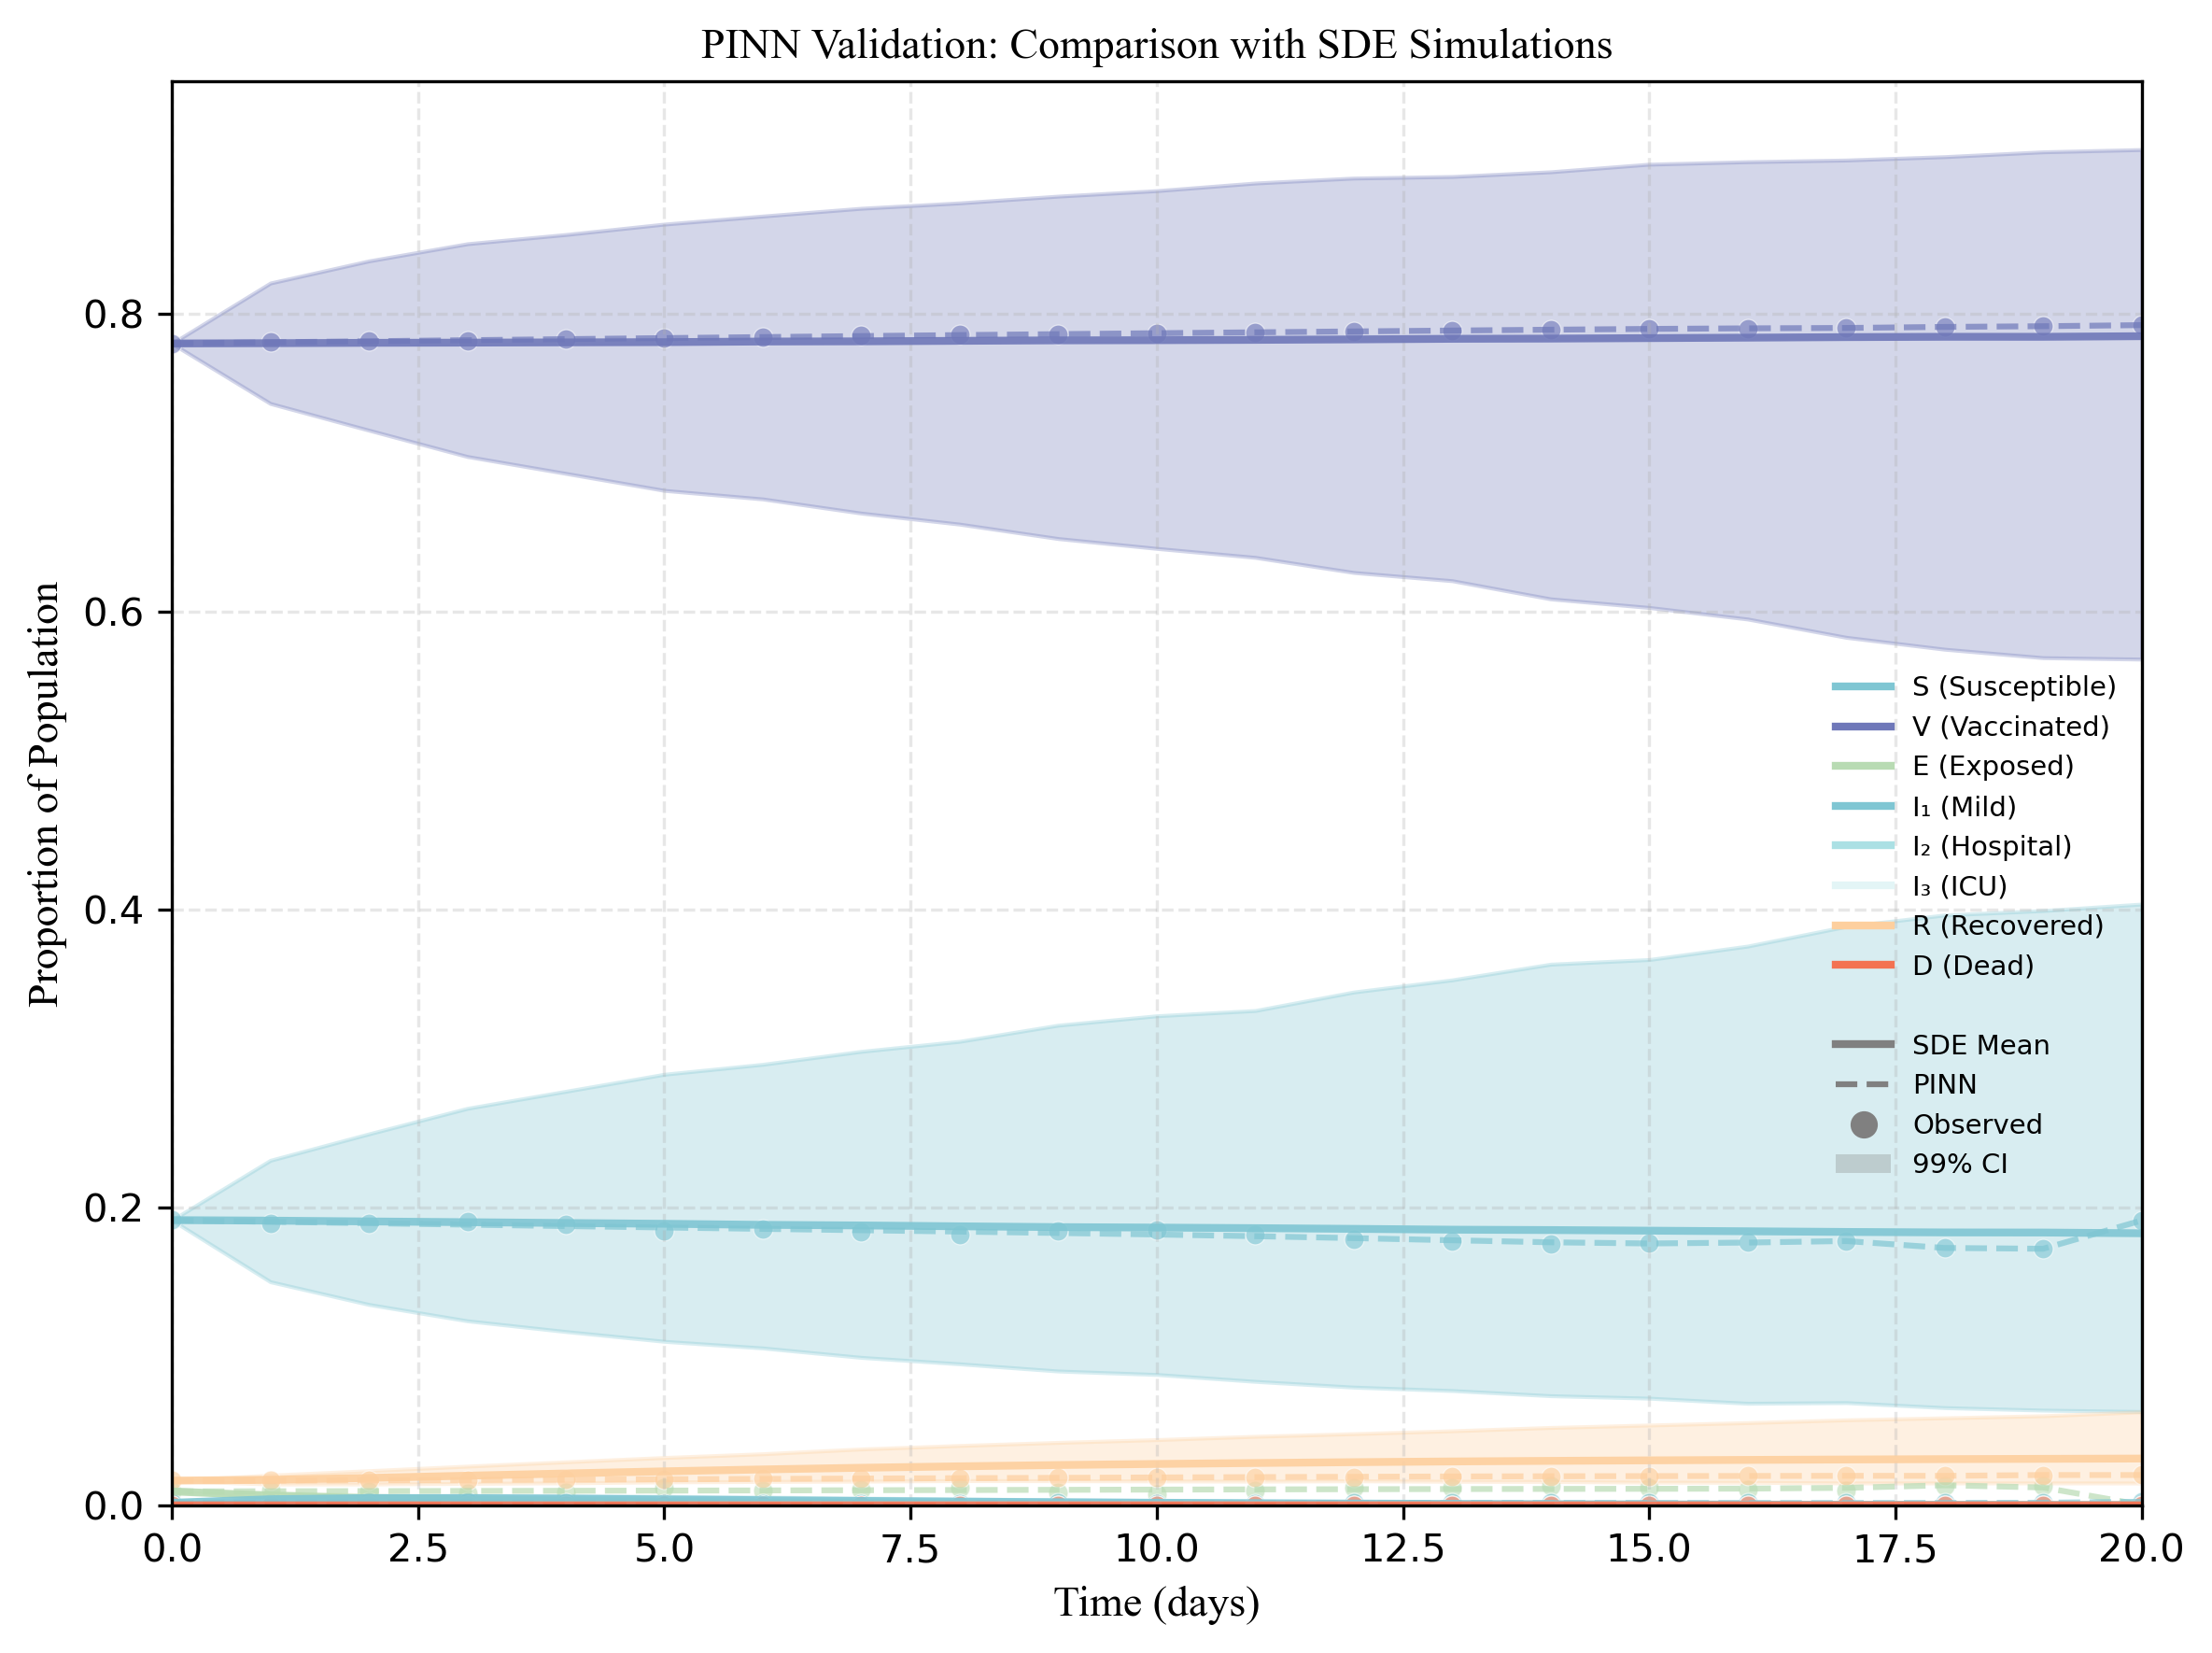

In [33]:
def plot_all_compartments_single_axis_with_ci(observed, pinn_pred, mean_sde, ci_lower, ci_upper,
                                               t_span, ci_label="99%"):
    """
    Plot all compartments on the same axis with different colors and CI bands.
    """

    new_purple = (111/255, 120/255, 185/255)
    m_orange = (253/255, 207/255, 158/255)
   
    m_blue = (209/255, 226/255, 239/255)
    m_green1 = (227/255, 245/255, 246/255)
    m_green2 = (171/255, 224/255, 228/255)
    m_green3 = (127/255, 198/255, 211/255)
    m_green = (184/255, 219/255, 179/255)
        # Color palette for 8 compartments
    colors = {
        'S': new_green,   # Red
        'V': new_purple,   # Blue
        'E': m_green,   # Green
        'I1': m_green3,  # Purple
        'I2': m_green2,  # Orange
        'I3': m_green1,  # Teal
        'R': m_orange,   # Dark gray
        'D': new_red,   # Pink
    }
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    labels = ['S (Susceptible)', 'V (Vaccinated)', 'E (Exposed)', 
              'I₁ (Mild)', 'I₂ (Hospital)', 'I₃ (ICU)', 
              'R (Recovered)', 'D (Dead)']
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    
    for comp, label in zip(compartments, labels):
        color = colors[comp]
        
        # CI band (shaded area) - no label
        ax.fill_between(t_span, np.maximum(ci_lower[comp], 0), ci_upper[comp], 
                        alpha=0.3, color=color)
        
        # SDE Mean (solid line)
        ax.plot(t_span, mean_sde[comp], '-', color=color, linewidth=2, 
                label=f'{label}', alpha=0.9)
        
        # PINN prediction (dashed line) - no label
        ax.plot(t_span, np.maximum(pinn_pred[comp], 0), '--', color=color, 
                linewidth=1.5, alpha=0.7)
        
        # Observed data (scatter) - no label
        step = max(1, len(observed[comp]) // 15)
        obs_idx = np.arange(0, len(observed[comp]), step)
        ax.scatter(t_span[obs_idx], observed[comp][obs_idx], 
                   c=color, s=25, marker='o', alpha=0.6, edgecolors='white', linewidth=0.3)
    
    # Add legend entries for line styles (using dummy plots)
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    # Create custom legend elements
    legend_elements = []
    
    # First: Compartment colors (solid lines)
    for comp, label in zip(compartments, labels):
        legend_elements.append(Line2D([0], [0], color=colors[comp], linewidth=2, label=label))
    
    # Separator
    legend_elements.append(Line2D([0], [0], color='none', label=''))  # Empty line as separator
    
    # Second: Line style meanings
    legend_elements.append(Line2D([0], [0], color='gray', linewidth=2, linestyle='-', label='SDE Mean'))
    legend_elements.append(Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', label='PINN'))
    legend_elements.append(Line2D([0], [0], color='gray', marker='o', linestyle='', markersize=6, label='Observed'))
    legend_elements.append(Patch(facecolor='gray', alpha=0.3, label=f'{ci_label} CI'))
    
    ax.set_xlabel('Time (days)', fontsize=11, family='Times New Roman')
    ax.set_ylabel('Proportion of Population', fontsize=11, family='Times New Roman')
    ax.set_title('PINN Validation: Comparison with SDE Simulations', fontsize=11, family='Times New Roman')
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 0.6), 
              fontsize=7, framealpha=0.0)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(t_span[0], t_span[-1])
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()
    
    return fig


# Call the function
fig = plot_all_compartments_single_axis_with_ci(
    observed, pinn_pred, mean_sde, ci_lower, ci_upper, t_span,
    ci_label=ci_label
)